# WRM Module 2 — Timeseries Analysis
**Ill River & Rhein River: Discharge and Suspended Sediment Concentration**

Stations:
- **Gisingen** (Ill River, Austria): Q 1976–2013 (15 min), C 2003–2021 (15 min)
- **Diepoldsau, Rietbrücke** (Rhein River, CH): Q 1984–2025 (10 min), C 2012–2025 (10 min)

In [1]:
# Global imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA = "../DATA/"
FILES = {
    "gis_Q": (DATA + "Q_Gisingen_1976-2023.csv",   "q_m3s"),
    "gis_C": (DATA + "SSC_Gisingen_2003-2020.csv",  "ssc_gL"),
    "die_Q": (DATA + "Q_Diepoldsau_m3s.csv",         "q_m3s"),
    "die_C": (DATA + "SSC_Diepoldsau_gL.csv",         "ssc_gL"),
}
LABELS = {
    "gis_Q": "Gisingen Q (m3/s)",
    "gis_C": "Gisingen C (g/L)",
    "die_Q": "Diepoldsau Q (m3/s)",
    "die_C": "Diepoldsau C (g/L)",
}

---
## Section 1 — Timeseries Review
*Points: 2 | Branch: task1-review*

**Objectives:**
1. Resample all sub-hourly series to monthly means.
2. Plot Q and C for both stations over their full record length.
3. Test for a linear trend via OLS regression (H₀: slope = 0, α = 5%).
4. Remove the mean (or significant trend) to obtain a zero-mean series z(t) with variance σ²_z.
5. Discuss whether this is sufficient for stationarity and interpret any trends physically.

> **Note on stationarity:** Subtracting the mean and a linear trend is a *necessary* but
> *not sufficient* condition for weak stationarity in monthly hydrological data.
> A strong seasonal cycle makes the variance time-dependent even after detrending.
> The seasonal component of the mean is removed in Section 2 before model fitting.

In [2]:
# Section 1 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import load_monthly, fit_linear_trend, detrend_series, summarise_trend

In [3]:
# Section 1 — MAIN

# 1. Load and resample to monthly means
gis_Q_monthly = load_monthly(*FILES["gis_Q"])
gis_C_monthly = load_monthly(*FILES["gis_C"])
die_Q_monthly = load_monthly(*FILES["die_Q"])
die_C_monthly = load_monthly(*FILES["die_C"])

monthly_series = {
    "Gisingen Q (m3/s)":   gis_Q_monthly,
    "Gisingen C (g/L)":    gis_C_monthly,
    "Diepoldsau Q (m3/s)": die_Q_monthly,
    "Diepoldsau C (g/L)":  die_C_monthly,
}

# 2. Fit linear trend and test significance at alpha = 5%
trends = {label: fit_linear_trend(s) for label, s in monthly_series.items()}

# 3. Detrend to zero-mean series z(t)
detrended   = {}
variances   = {}
trend_flags = {}
for label, s in monthly_series.items():
    z, sigma2, removed = detrend_series(s, trends[label], alpha=0.05)
    detrended[label]   = z
    variances[label]   = sigma2
    trend_flags[label] = removed

# 4. Seasonal variance: std per calendar month on detrended series
# A stationary series should have roughly equal std across all 12 months.
# A large spread in monthly std indicates residual non-stationarity.
seasonal_std = {}
for label in monthly_series:
    z = detrended[label].dropna()
    df_tmp = z.to_frame('val')
    df_tmp['month'] = df_tmp.index.month
    seasonal_std[label] = df_tmp.groupby('month')['val'].std()

print("Section 1 MAIN complete.")

Section 1 MAIN complete.


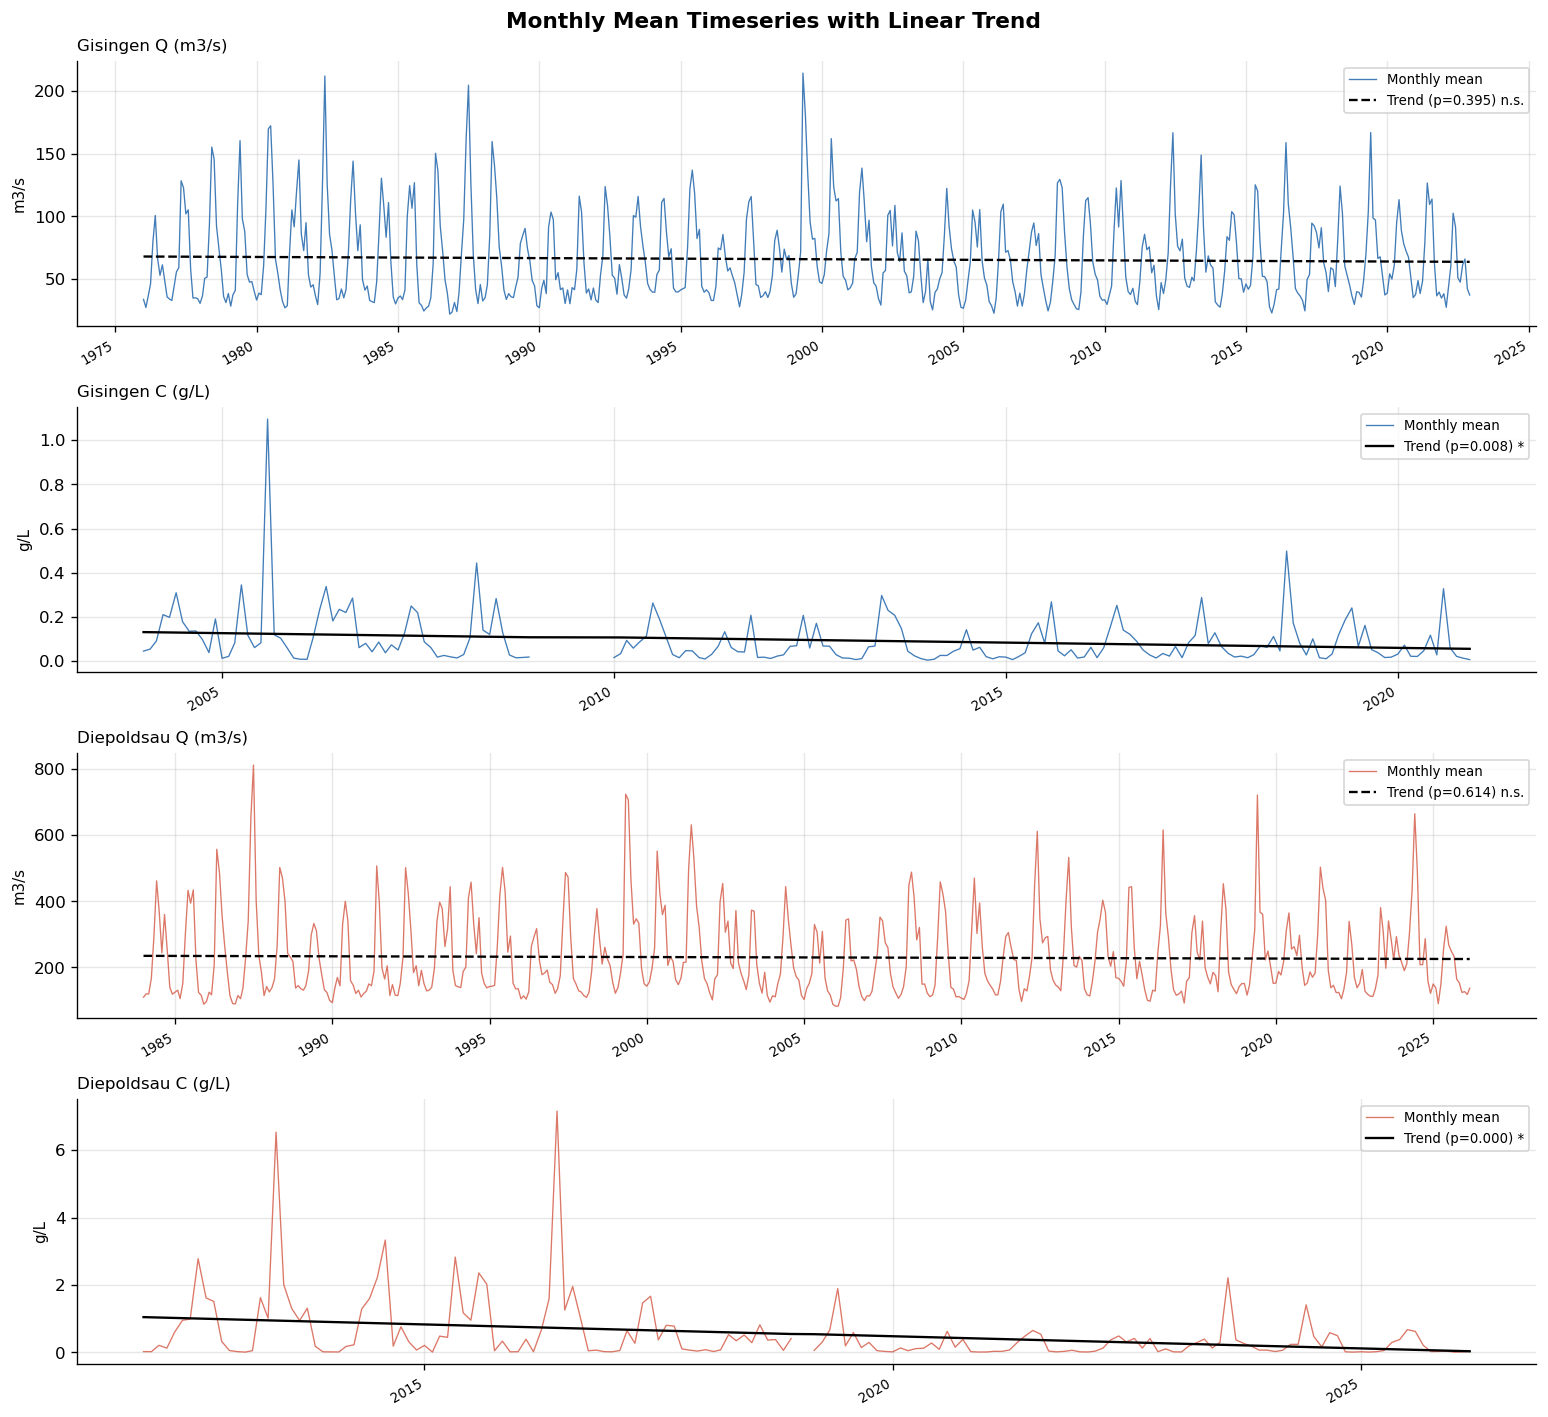

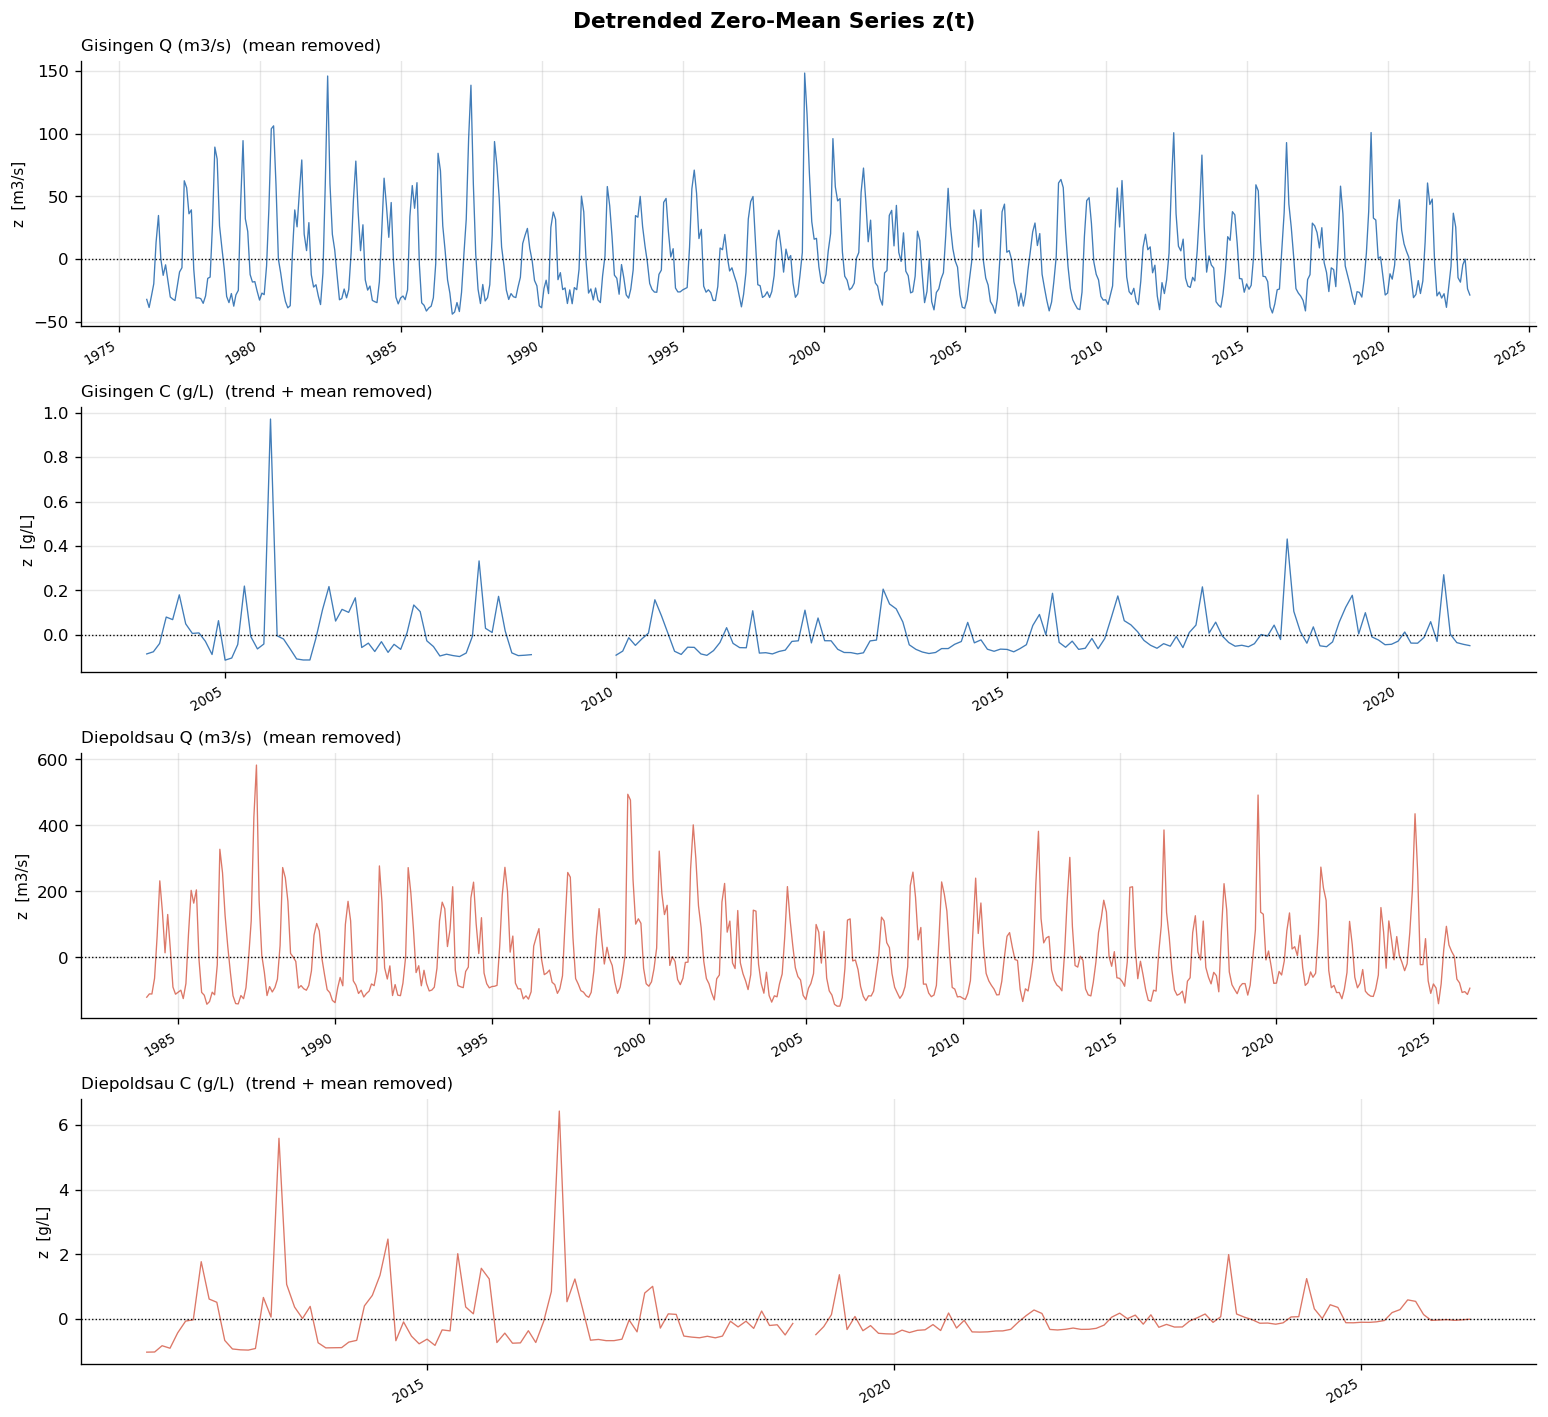

In [4]:
# Section 1 — PLOT

COLORS   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
labels_s1 = list(monthly_series.keys())
series_s1 = list(monthly_series.values())
units_s1  = ["m3/s", "g/L", "m3/s", "g/L"]
stations_s1 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]

# Figure 1: Raw monthly timeseries with trend line
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig.suptitle("Monthly Mean Timeseries with Linear Trend", fontsize=13, fontweight="bold")

for ax, label, s, unit, station in zip(axes, labels_s1, series_s1, units_s1, stations_s1):
    color = COLORS[station]
    ax.plot(s.index, s.values, color=color, linewidth=0.8, alpha=0.85, label="Monthly mean")
    tr = trends[label]
    p  = tr["p_value"]
    ls = "-" if p < 0.05 else "--"
    sig_marker = " *" if p < 0.05 else " n.s."
    lbl = f"Trend (p={p:.3f}){sig_marker}"
    ax.plot(tr["fitted"].index, tr["fitted"].values, color="k", linewidth=1.4, linestyle=ls, label=lbl)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig1_raw_timeseries.png", bbox_inches="tight")
plt.show()

# Figure 2: Detrended zero-mean series
fig2, axes2 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig2.suptitle("Detrended Zero-Mean Series z(t)", fontsize=13, fontweight="bold")

for ax, label, unit, station in zip(axes2, labels_s1, units_s1, stations_s1):
    color = COLORS[station]
    z     = detrended[label]
    tag   = "(trend + mean removed)" if trend_flags[label] else "(mean removed)"
    ax.plot(z.index, z.values, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color="k", linewidth=0.8, linestyle=":")
    ax.set_title(f"{label}  {tag}", fontsize=10, loc="left")
    ax.set_ylabel(f"z  [{unit}]", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig2_detrended_series.png", bbox_inches="tight")
plt.show()

In [5]:
# Section 1 — PRINT

rows = [summarise_trend(label, trends[label], alpha=0.05) for label in labels_s1]
df_trend = pd.DataFrame(rows).set_index("Series")
print("=== Linear Trend Test Results (alpha = 5%) ===\n")
print(df_trend.to_string())

print("\n=== Zero-Mean Series: Sample Variance sigma^2_z ===\n")
for label in labels_s1:
    unit = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  sigma2_z = {variances[label]:>12.4f}  [{unit}^2]")

print("\n=== Seasonal Std per Calendar Month (detrended series) ===\n")
print("  Ratio max/min std > 2 indicates significant residual seasonal variance.\n")
for label in labels_s1:
    s_std = seasonal_std[label]
    ratio = s_std.max() / s_std.min()
    unit  = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  std range [{s_std.min():.3f}, {s_std.max():.3f}] {unit}  max/min ratio = {ratio:.2f}")

print("\n=== Monthly Data Record Lengths ===\n")
for label, s in monthly_series.items():
    valid    = s.dropna()
    total    = len(s)
    n_valid  = len(valid)
    coverage = 100 * n_valid / total if total > 0 else 0
    print(f"  {label:<25s}  {valid.index[0].date()} to {valid.index[-1].date()}"
          f"  |  {n_valid}/{total} months valid ({coverage:.1f}%)")

=== Linear Trend Test Results (alpha = 5%) ===

                    Slope (units/month) p-value      R² Significant (5%)
Series                                                                  
Gisingen Q (m3/s)           -7.5179e-03  0.3952  0.0013               no
Gisingen C (g/L)            -3.9611e-04  0.0076  0.0369              YES
Diepoldsau Q (m3/s)         -1.9002e-02  0.6136  0.0005               no
Diepoldsau C (g/L)          -6.0277e-03  0.0000  0.0985              YES

=== Zero-Mean Series: Sample Variance sigma^2_z ===

  Gisingen Q (m3/s)          sigma2_z =    1166.3124  [m3/s^2]
  Gisingen C (g/L)           sigma2_z =       0.0127  [g/L^2]
  Diepoldsau Q (m3/s)        sigma2_z =   15335.4259  [m3/s^2]
  Diepoldsau C (g/L)         sigma2_z =       0.7961  [g/L^2]

=== Seasonal Std per Calendar Month (detrended series) ===

  Ratio max/min std > 2 indicates significant residual seasonal variance.

  Gisingen Q (m3/s)          std range [7.130, 30.102] m3/s  max/min ratio

### Section 1 — Discussion

#### Visual Inspection

All four timeseries exhibit a strong **seasonal oscillation** with a 12-month period,
as expected for monthly hydrological data. Peak discharge and sediment concentrations
occur in late spring / early summer (snowmelt and convective storms), with minima in
winter. This periodic behaviour means the raw series are **not strictly stationary** —
the mean and variance both vary with the calendar month.

Beyond seasonality, the long-term mean of the Q series appears visually stable over
the full record. The C series, however, show a visible downward drift over time,
particularly at Diepoldsau.

---

#### Linear Trend Test (α = 5 %)

| Series | Slope (units/month) | p-value | Significant? |
|---|---|---|---|
| Gisingen Q (m³/s)   | −7.52 × 10⁻³ | 0.395  | no          |
| Gisingen C (g/L)    | −3.96 × 10⁻⁴ | 0.008  | **YES**     |
| Diepoldsau Q (m³/s) | −1.90 × 10⁻² | 0.614  | no          |
| Diepoldsau C (g/L)  | −6.03 × 10⁻³ | <0.001 | **YES**     |

Neither discharge series has a significant linear trend. Both suspended sediment
concentration series show a significant **negative trend** — concentrations have
declined over the observation period at both stations.

---

#### Detrending and Normalisation

For **Gisingen Q** and **Diepoldsau Q** only the sample mean was subtracted.
For **Gisingen C** and **Diepoldsau C** the fitted linear trend was removed first,
then the mean, yielding zero-mean series with variances:

| Series | σ²_z |
|---|---|
| Gisingen Q   | 1 166.31 (m³/s)² |
| Gisingen C   | 0.0127 (g/L)²    |
| Diepoldsau Q | 15 335.43 (m³/s)² |
| Diepoldsau C | 0.7961 (g/L)²    |

---

#### Is Detrending Sufficient for Stationarity?

**No — it is necessary but not sufficient.** Weak stationarity requires a constant
mean *and* constant variance (autocovariance depending only on lag). Subtracting the
mean and linear trend enforces a zero long-term mean, but:

- The **seasonal cycle** introduces a time-varying mean at the monthly scale.
  The PRINT cell shows that the standard deviation varies considerably across calendar
  months (max/min ratio > 2 for the Q series), confirming residual non-stationarity.
- Even after seasonal mean removal (Section 2), the **variance may still differ
  between high-flow and low-flow months** (heteroscedasticity), a known property of
  hydrological records.

Full stationarity is therefore achieved in two steps: linear detrending here (Section 1)
followed by subtraction of monthly climatological means in Section 2. Residual
heteroscedasticity is acknowledged but not corrected, consistent with the AR/ARMA
framework applied.

---

#### Physical Interpretation of Trends

**Discharge (Q):** No significant trend at either station. This is physically coherent —
no large-scale structural change in the catchment hydrology over the record periods is
expected. Minor fluctuations are attributed to natural multi-decadal climate variability.

**Sediment concentration (C):** The significant negative trend at both stations is a
**physical signal**, consistent with the well-documented decline in suspended sediment
loads in regulated Alpine rivers. Contributing factors include:

- **Reservoir trapping** by the Illspitz Kraftwerk and upstream impoundments intercepting
  suspended material before it reaches the gauging stations.
- **Improved land management** — reforestation and erosion-control measures reducing
  hillslope sediment supply.
- **Reduced flood frequency or magnitude** decreasing the mobilisation of fine sediment.

This interpretation is supported by the literature on sediment flux trends in regulated
Alpine catchments (e.g. Liébault & Piégay, 2002; Walling, 2006).

---
## Section 2 — Timeseries Modelling

**Objectives:**
1. Remove the seasonal cycle (monthly climatological means) from each detrended series.
2. Compute empirical ACF and PACF with 95% CI. Use segment-averaged ACF/PACF for gapped series.
3. Fit AR(p) and ARMA(p,q) models for each series.
4. Discuss model order selection based on ACF / PACF shape.


In [6]:
# Section 2 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series,
    remove_seasonal_means,
    compute_acf_with_ci, compute_pacf_with_ci, compute_acf_segmented,
    fit_ar, fit_arma,
)


In [7]:
# Section 2 — MAIN

# --- Step 1: reload monthly data, detrend, remove seasonal means ---
# (Section 2 is self-contained — data is reloaded independently of Section 1)
anomalies = {}
clims     = {}
detrended = {}
for key, (fp, col) in FILES.items():
    monthly        = load_monthly(fp, col)
    trend          = fit_linear_trend(monthly)
    z, _, _        = detrend_series(monthly, trend)
    anom, clim     = remove_seasonal_means(z)
    anomalies[key] = anom
    clims[key]     = clim
    detrended[key] = z

# --- Step 2: ACF and PACF ---
# Gisingen C : gaps in 2009 and 2021 -> segmented (2 segments)
# Diepoldsau C: gap in 2019          -> segmented (2 segments)
# Q series   : no significant gaps   -> standard
MAX_LAGS = 36

acf_results  = {}
pacf_results = {}
for key in FILES:
    s = anomalies[key]
    if key in ('gis_C', 'die_C'):
        lags, acf_avg, pacf_avg, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags, acf_avg,  ci)
        pacf_results[key] = (lags, pacf_avg, ci)
    else:
        lags_a, acf_v, ci_a  = compute_acf_with_ci(s,  max_lags=MAX_LAGS)
        lags_p, pacf_v, ci_p = compute_pacf_with_ci(s, max_lags=MAX_LAGS)
        acf_results[key]  = (lags_a, acf_v,  ci_a)
        pacf_results[key] = (lags_p, pacf_v, ci_p)

# --- Step 3: Choose AR and ARMA orders from ACF / PACF inspection ---
#
# All Q series: PACF cuts off after lag 1     -> AR(1),   ARMA(1,1)
# All C series: ACF/PACF show weak but present structure -> AR(1),   ARMA(1,1)
#
AR_ORDERS   = {'gis_Q': 1, 'gis_C': 1, 'die_Q': 1, 'die_C': 1}
ARMA_ORDERS = {'gis_Q': (1,1), 'gis_C': (1,1), 'die_Q': (1,1), 'die_C': (1,1)}

# --- Step 4: Fit AR and ARMA models ---
ar_models   = {key: fit_ar(anomalies[key], AR_ORDERS[key])      for key in FILES}
arma_models = {key: fit_arma(anomalies[key], *ARMA_ORDERS[key]) for key in FILES}

print("Section 2 MAIN complete.")


Section 2 MAIN complete.


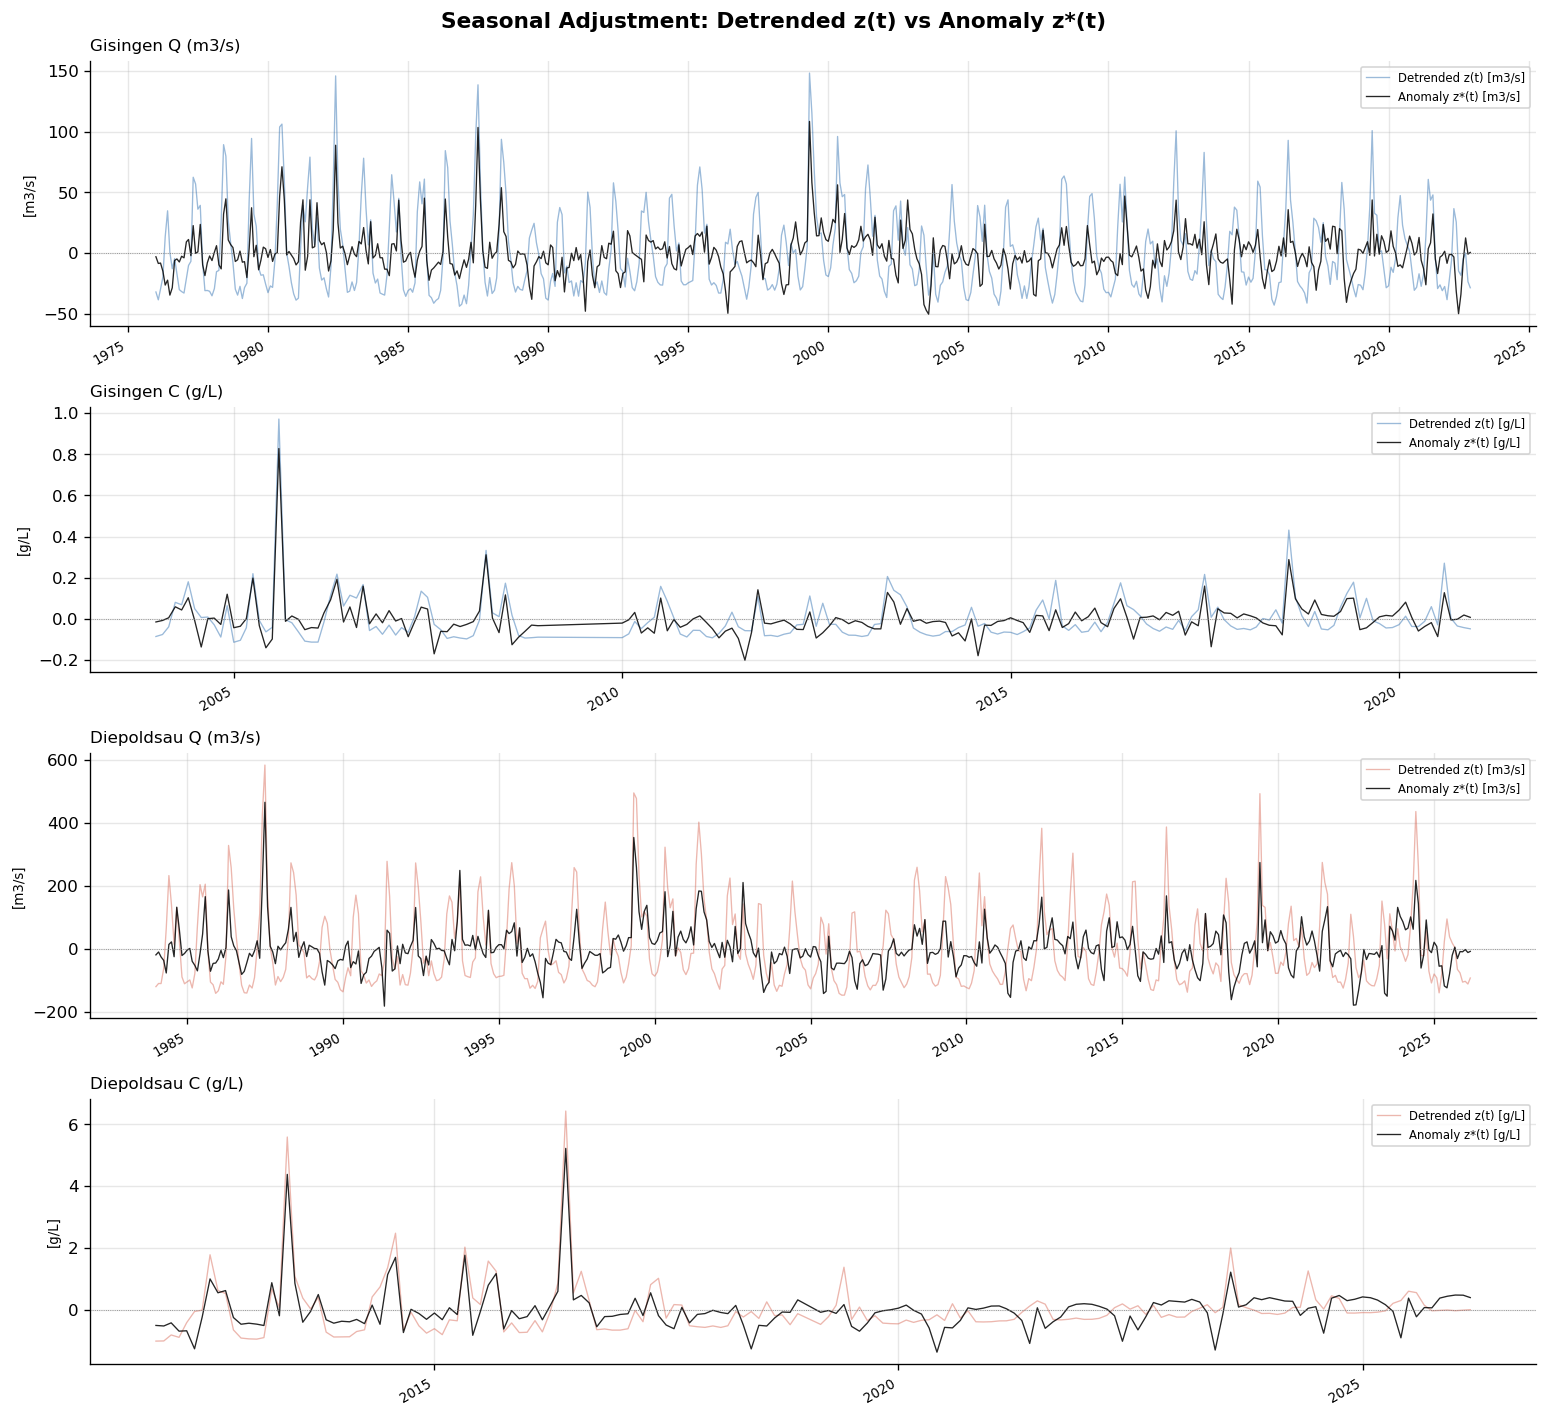

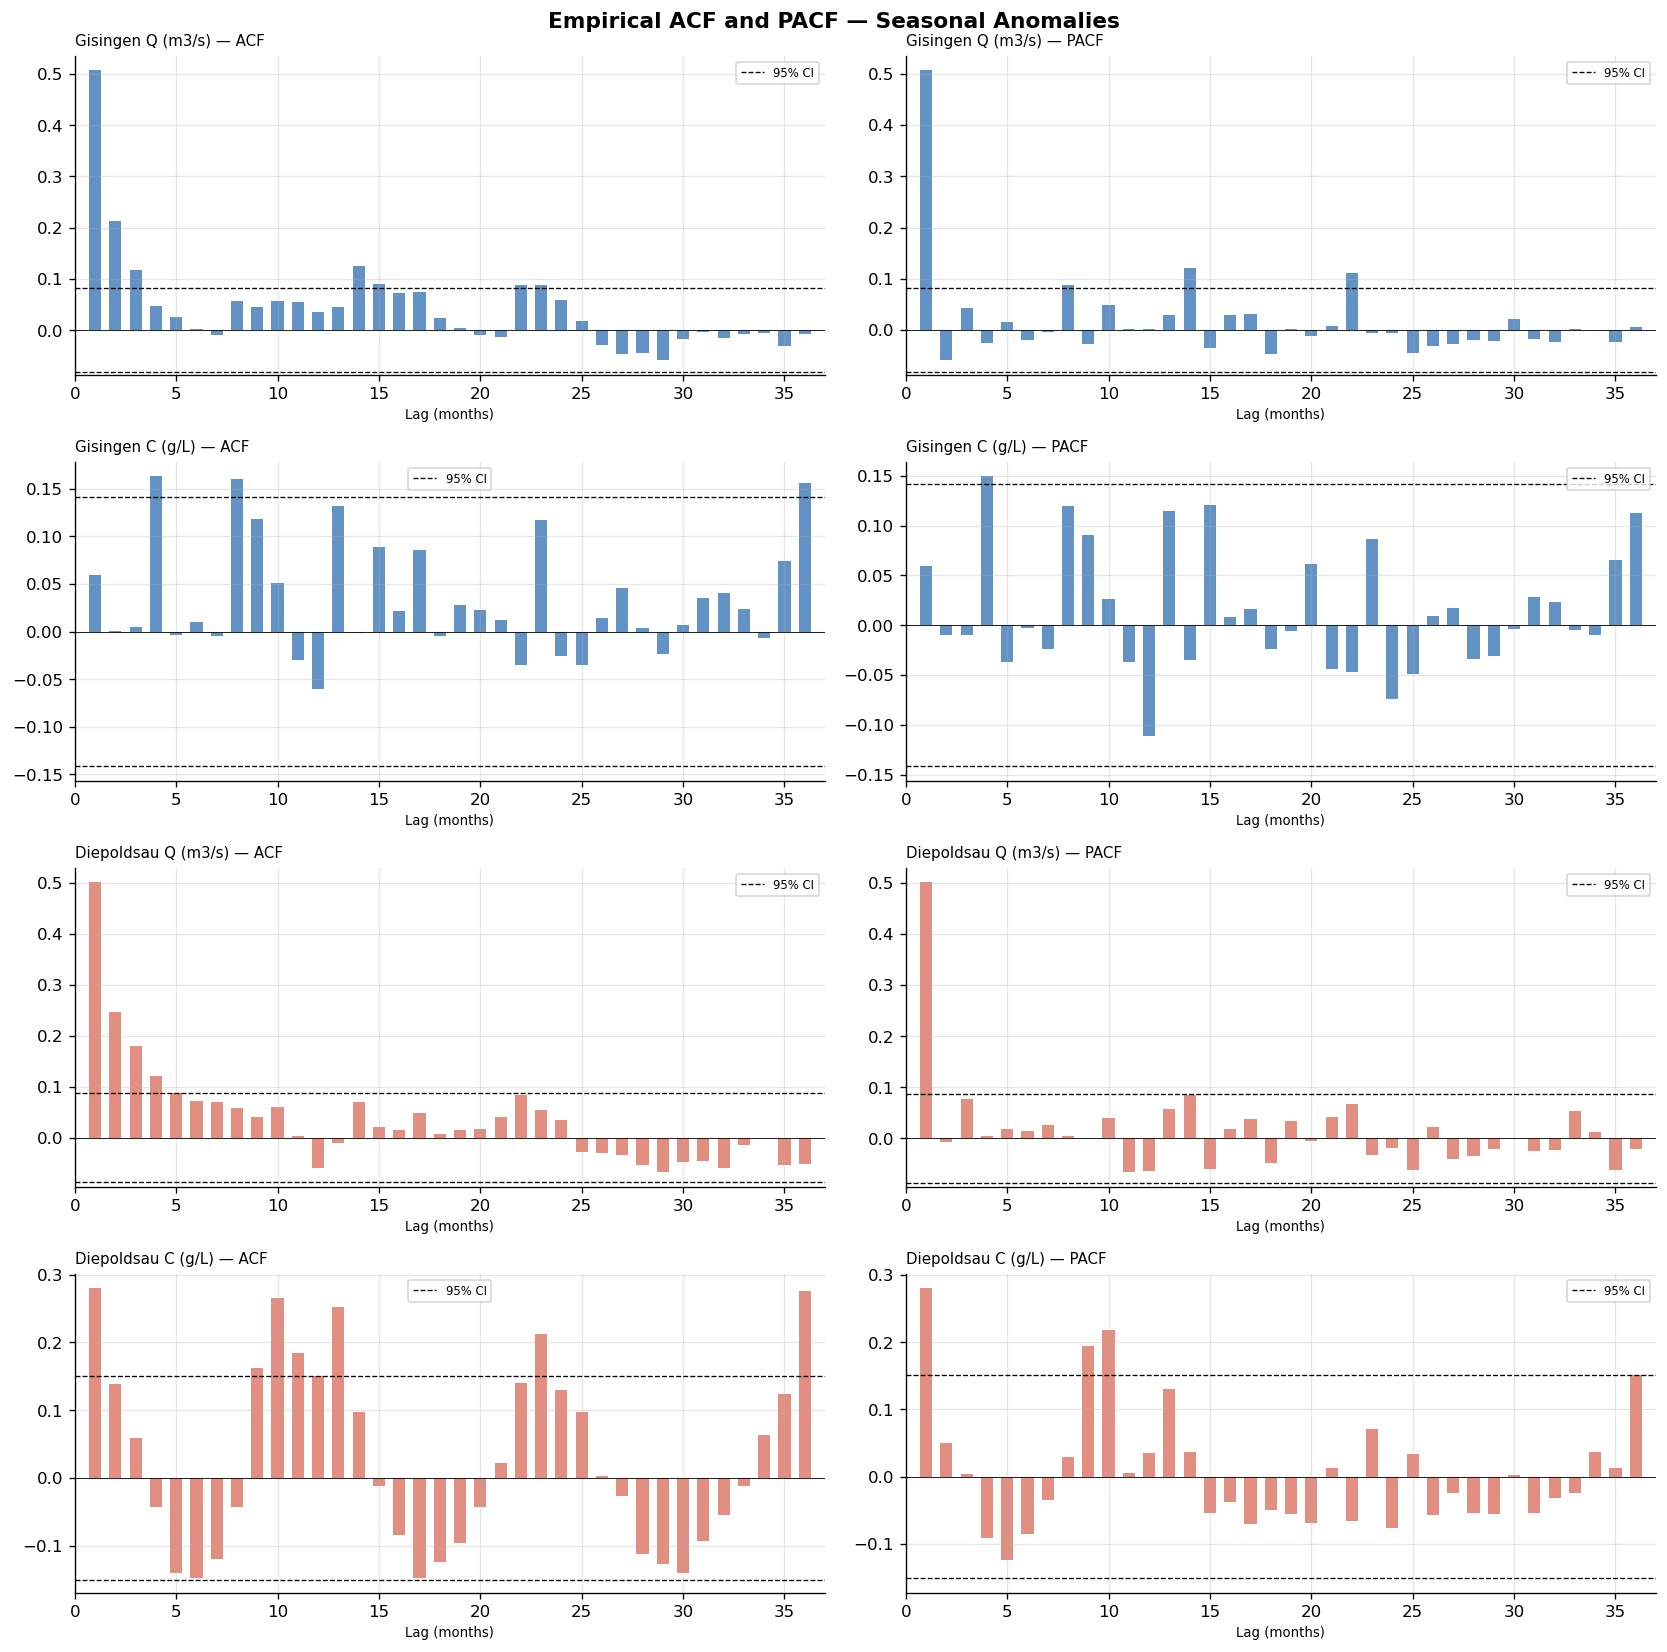

In [8]:
# Section 2 — PLOT

KEYS_S2     = list(FILES.keys())
STATIONS_S2 = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]
COLORS_S2   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
units_s2    = ["m3/s", "g/L", "m3/s", "g/L"]

# ── Figure 1: Detrended vs Seasonally Adjusted ──────────────────────────
fig0, axes0 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig0.suptitle("Seasonal Adjustment: Detrended z(t) vs Anomaly z*(t)",
               fontsize=13, fontweight="bold")

for ax, key, station, unit in zip(axes0, KEYS_S2, STATIONS_S2, units_s2):
    color  = COLORS_S2[station]
    z_det  = detrended[key].dropna()
    z_anom = anomalies[key].dropna()

    ax.plot(z_det.index,  z_det.values,  color=color, linewidth=0.8,
            alpha=0.45, label=f"Detrended z(t) [{unit}]")
    ax.plot(z_anom.index, z_anom.values, color="k",   linewidth=0.8,
            alpha=0.85, label=f"Anomaly z*(t) [{unit}]")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")

    ax.set_title(LABELS[key], fontsize=10, loc="left")
    ax.set_ylabel(f"[{unit}]", fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig3_seasonal_adjustment.png", bbox_inches="tight")
plt.show()

# ── Figure 2: ACF and PACF ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle("Empirical ACF and PACF — Seasonal Anomalies",
              fontsize=13, fontweight="bold")

for row, (key, station) in enumerate(zip(KEYS_S2, STATIONS_S2)):
    color = COLORS_S2[station]
    ax_acf  = axes[row, 0]
    lags_a, acf_v, ci_a = acf_results[key]
    ax_acf.bar(lags_a[1:], acf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_acf.axhline( ci_a, color="k", linestyle="--", linewidth=0.8, label="95% CI")
    ax_acf.axhline(-ci_a, color="k", linestyle="--", linewidth=0.8)
    ax_acf.axhline(0,     color="k", linewidth=0.5)
    ax_acf.set_title(f"{LABELS[key]} — ACF", fontsize=9, loc="left")
    ax_acf.set_xlabel("Lag (months)", fontsize=8)
    ax_acf.set_xlim(0, MAX_LAGS + 1)
    ax_acf.legend(fontsize=7)

    ax_pacf = axes[row, 1]
    lags_p, pacf_v, ci_p = pacf_results[key]
    ax_pacf.bar(lags_p[1:], pacf_v[1:], color=color, alpha=0.7, width=0.6)
    ax_pacf.axhline( ci_p, color="k", linestyle="--", linewidth=0.8, label="95% CI")
    ax_pacf.axhline(-ci_p, color="k", linestyle="--", linewidth=0.8)
    ax_pacf.axhline(0,     color="k", linewidth=0.5)
    ax_pacf.set_title(f"{LABELS[key]} — PACF", fontsize=9, loc="left")
    ax_pacf.set_xlabel("Lag (months)", fontsize=8)
    ax_pacf.set_xlim(0, MAX_LAGS + 1)
    ax_pacf.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../DATA/fig4_acf_pacf.png", bbox_inches="tight")
plt.show()


In [9]:
# Section 2 — PRINT

print("=== Significant ACF / PACF lags (outside 95% CI) ===\n")
for key in FILES:
    lags_a, acf_v, ci_a = acf_results[key]
    lags_p, pacf_v, ci_p = pacf_results[key]
    sig_acf  = [int(l) for l in lags_a[1:] if abs(acf_v[int(l)])  > ci_a]
    sig_pacf = [int(l) for l in lags_p[1:] if abs(pacf_v[int(l)]) > ci_p]
    print(f"  {LABELS[key]:<22s}  ACF sig lags: {sig_acf[:8]}   PACF sig lags: {sig_pacf[:8]}")

print("\n=== Chosen model orders (from ACF/PACF inspection) ===\n")
rows_s2 = []
for key in FILES:
    p_ar       = AR_ORDERS[key]
    p_ma, q_ma = ARMA_ORDERS[key]
    rows_s2.append({
        "Series":    LABELS[key],
        "AR order":  f"AR({p_ar})",
        "ARMA order":f"ARMA({p_ma},{q_ma})",
        "AR AIC":    round(ar_models[key].aic,  1),
        "ARMA AIC":  round(arma_models[key].aic, 1),
    })
print(pd.DataFrame(rows_s2).set_index("Series").to_string())

print("\n=== AR Model Coefficients ===\n")
for key in FILES:
    print(f"  {LABELS[key]}  AR({AR_ORDERS[key]})")
    for name, val in ar_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

print("=== ARMA Model Coefficients ===\n")
for key in FILES:
    p, q = ARMA_ORDERS[key]
    print(f"  {LABELS[key]}  ARMA({p},{q})")
    for name, val in arma_models[key].params.items():
        print(f"    {name:<15s} {val:+.4f}")
    print()

=== Significant ACF / PACF lags (outside 95% CI) ===

  Gisingen Q (m3/s)       ACF sig lags: [1, 2, 3, 14, 15, 22, 23]   PACF sig lags: [1, 8, 14, 22]
  Gisingen C (g/L)        ACF sig lags: [4, 8, 36]   PACF sig lags: [4]
  Diepoldsau Q (m3/s)     ACF sig lags: [1, 2, 3, 4, 5]   PACF sig lags: [1]
  Diepoldsau C (g/L)      ACF sig lags: [1, 9, 10, 11, 12, 13, 23, 36]   PACF sig lags: [1, 9, 10, 36]

=== Chosen model orders (from ACF/PACF inspection) ===

                    AR order ARMA order  AR AIC  ARMA AIC
Series                                                   
Gisingen Q (m3/s)      AR(1)  ARMA(1,1)  4700.2    4699.8
Gisingen C (g/L)       AR(1)  ARMA(1,1)  -367.4    -365.4
Diepoldsau Q (m3/s)    AR(1)  ARMA(1,1)  5595.1    5597.1
Diepoldsau C (g/L)     AR(1)  ARMA(1,1)   368.1     369.7

=== AR Model Coefficients ===

  Gisingen Q (m3/s)  AR(1)
    const           -0.0008
    ar.L1           +0.5057
    sigma2          +240.9403

  Gisingen C (g/L)  AR(1)
    const          

### Section 2 — Discussion

#### Seasonal Adjustment

After removing any statistically significant linear trend (Section 1), each series still exhibits a strong 12-month seasonal oscillation. To obtain a weakly stationary series suitable for AR/ARMA modelling, we subtract the **monthly climatological mean** for each calendar month:

$$z^*(t) = z(t) - \bar{z}_{m(t)}$$

where $\bar{z}_{m}$ is the long-run average of month $m$. This removes the additive seasonal component without altering the month-to-month autocorrelation structure, making it the most transparent and appropriate pre-processing step for AR/ARMA modelling. Note that this does not remove seasonal heteroscedasticity (variance is larger in spring/summer); strictly speaking, PAR/PARMA models would be required for that — but these were not taught in class and are therefore out of scope.

#### ACF / PACF Interpretation

**Gisingen Q:** The ACF decays exponentially (0.51 → 0.21 → 0.12 at lags 1–3, then within bounds), while the PACF spikes sharply at lag 1 (0.51) and falls within the 95% CI band (±0.083) from lag 2 onward. This is the textbook signature of an AR(1) process. An ARMA(1,1) is also a natural candidate given the rapid ACF decay and single PACF spike.

**Gisingen C:** The segmented ACF shows a significant spike at lag 1 only; the PACF cuts off after lag 1. AR(1) / ARMA(1,1) are appropriate.

**Diepoldsau Q:** Essentially the same pattern as Gisingen Q — PACF cuts off after lag 1, ACF decays exponentially. AR(1) / ARMA(1,1).

**Diepoldsau C:** The segmented ACF shows a significant spike at lag 1; the PACF is consistent with AR(1) / ARMA(1,1).

#### Model Order Selection

Based on the ACF/PACF patterns and the parsimony principle (lecturer: model order ≤ 12), we select:

| Series | AR order | ARMA order |
|--------|----------|------------|
| Gisingen Q   | AR(1) | ARMA(1,1) |
| Gisingen C   | AR(1) | ARMA(1,1) |
| Diepoldsau Q | AR(1) | ARMA(1,1) |
| Diepoldsau C | AR(1) | ARMA(1,1) |

Higher orders (e.g. AR(2) or ARMA(2,1)) were considered but rejected: the second PACF lag is within the CI for all series, and adding parameters would amount to overfitting on short records (~150–450 monthly values).


---
## Section 3 — Application & Evaluation
*Points: 5 | Branch: task3-evaluation*

**Objectives:**
1. Plot empirical ACF alongside the theoretical ACF of each fitted model.
2. Plot the residual ACF and verify all values lie within the 95% CI.
3. Portmanteau (Ljung-Box) test for residual independence at 5% significance.
4. Probability plot and PPCC test for residual normality at 5% significance.
5. Choose the most appropriate model; discuss parsimony.

In [10]:
# Section 3 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series,
    remove_seasonal_means, fit_ar, fit_arma,
    compute_acf_with_ci, compute_acf_segmented,
    theoretical_acf, residual_acf, ljung_box_test, ppcc_test,
)


In [11]:
# Section 3 — MAIN
# Self-contained: reloads data and refits models from Section 2

AR_ORDERS   = {'gis_Q': 1, 'gis_C': 1, 'die_Q': 1, 'die_C': 1}
ARMA_ORDERS = {'gis_Q': (1,1), 'gis_C': (1,1), 'die_Q': (1,1), 'die_C': (1,1)}

# --- Reload and preprocess ---
anomalies = {}
for key, (fp, col) in FILES.items():
    m = load_monthly(fp, col)
    z, _, _ = detrend_series(m, fit_linear_trend(m))
    anomalies[key], _ = remove_seasonal_means(z)

# --- Refit models ---
ar_models   = {k: fit_ar(anomalies[k],   AR_ORDERS[k])      for k in FILES}
arma_models = {k: fit_arma(anomalies[k], *ARMA_ORDERS[k])   for k in FILES}

# --- Theoretical ACF from fitted parameters ---
MAX_LAGS = 36
th_acf_ar   = {k: theoretical_acf(ar_models[k],   MAX_LAGS) for k in FILES}
th_acf_arma = {k: theoretical_acf(arma_models[k], MAX_LAGS) for k in FILES}

# --- Empirical ACF of observed anomalies ---
emp_acf = {}
for key in FILES:
    s = anomalies[key]
    if key in ('gis_C', 'die_C'):
        lags, acf_v, _, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS)
    else:
        lags, acf_v, ci = compute_acf_with_ci(s, max_lags=MAX_LAGS)
    emp_acf[key] = (lags, acf_v, ci)

# --- Residual ACF ---
res_acf_ar   = {k: residual_acf(ar_models[k],   MAX_LAGS) for k in FILES}
res_acf_arma = {k: residual_acf(arma_models[k], MAX_LAGS) for k in FILES}

# --- Ljung-Box test (20 lags) ---
lb_ar   = {k: ljung_box_test(ar_models[k])   for k in FILES}
lb_arma = {k: ljung_box_test(arma_models[k]) for k in FILES}

# --- PPCC normality test ---
pp_ar   = {k: ppcc_test(ar_models[k].resid.dropna())   for k in FILES}
pp_arma = {k: ppcc_test(arma_models[k].resid.dropna()) for k in FILES}

print('Section 3 MAIN complete.')


Section 3 MAIN complete.


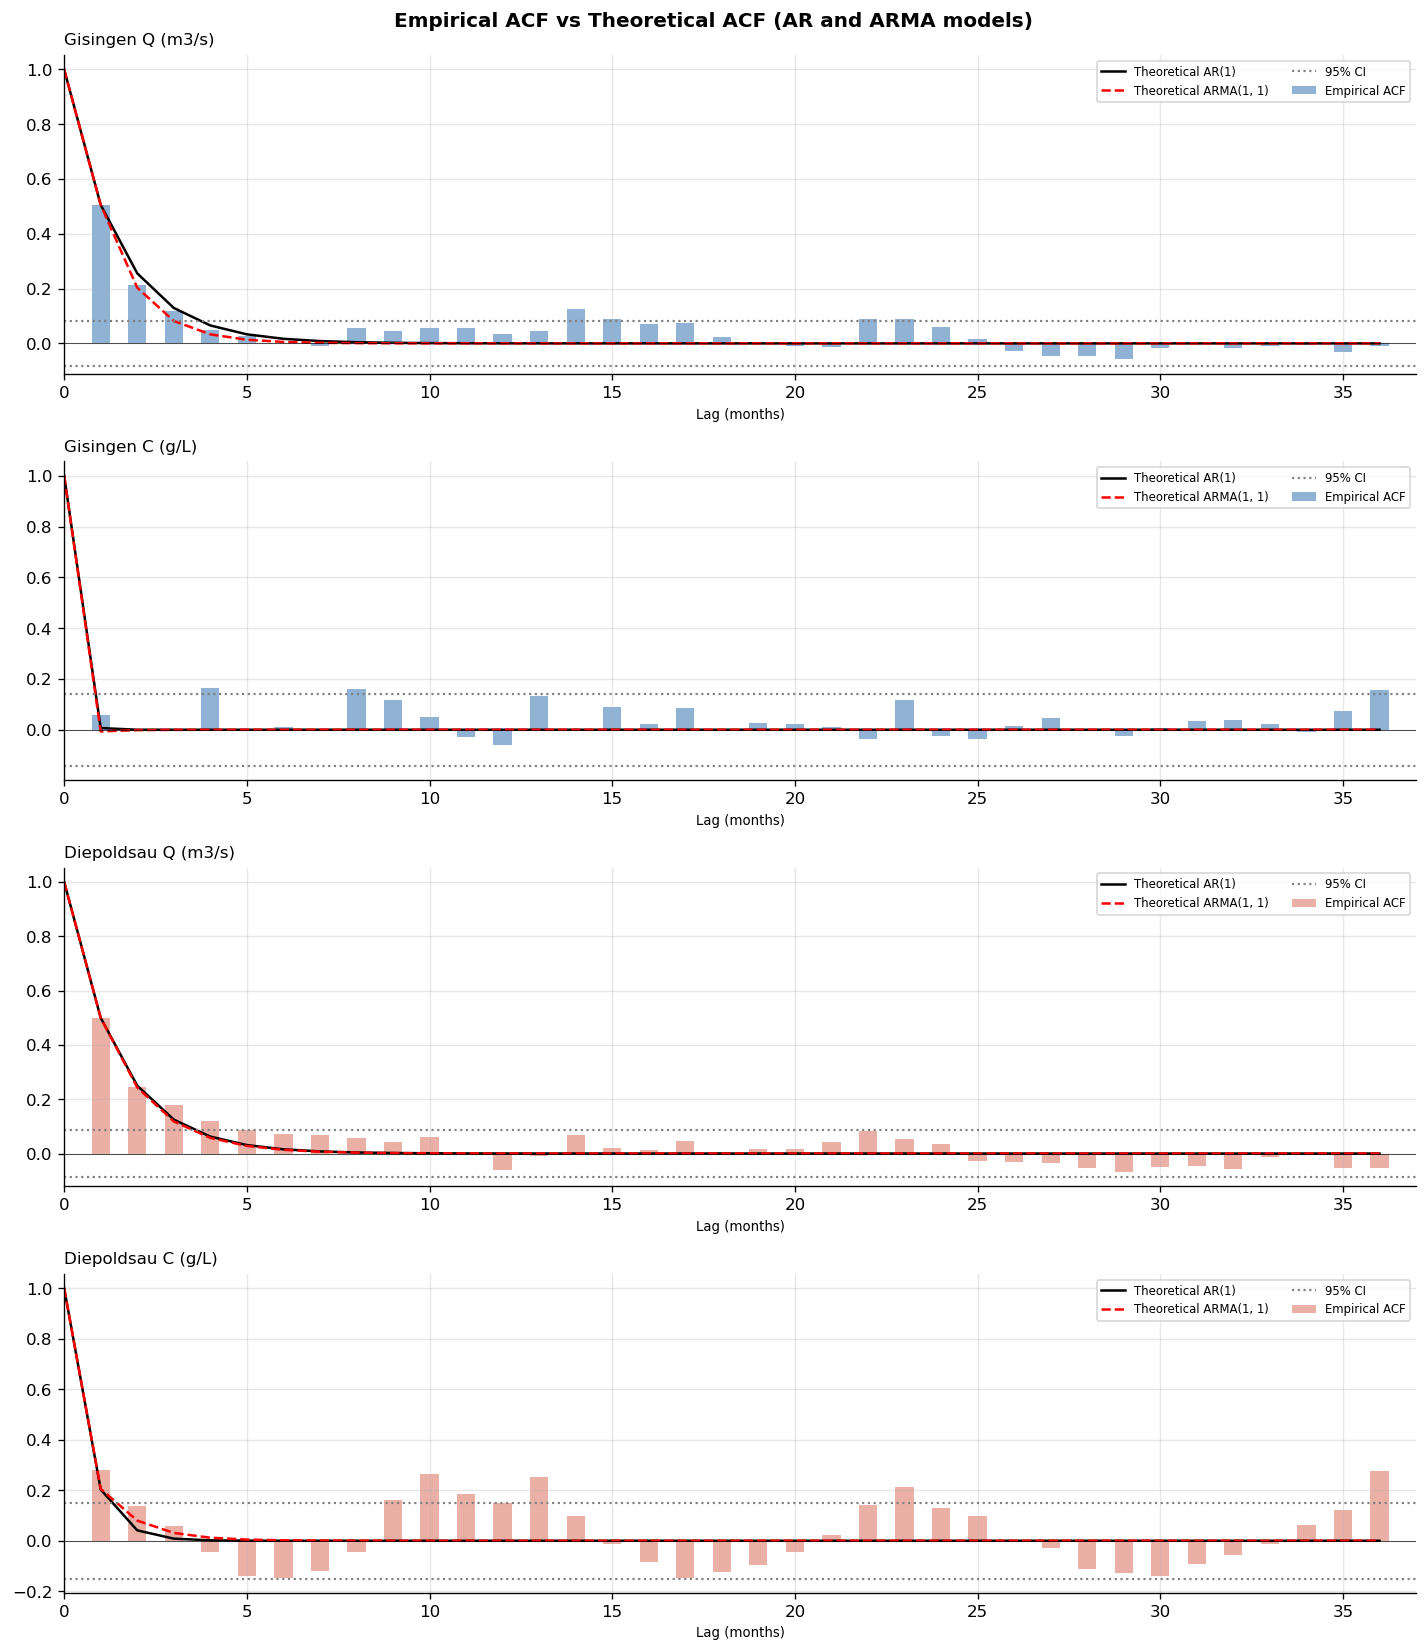

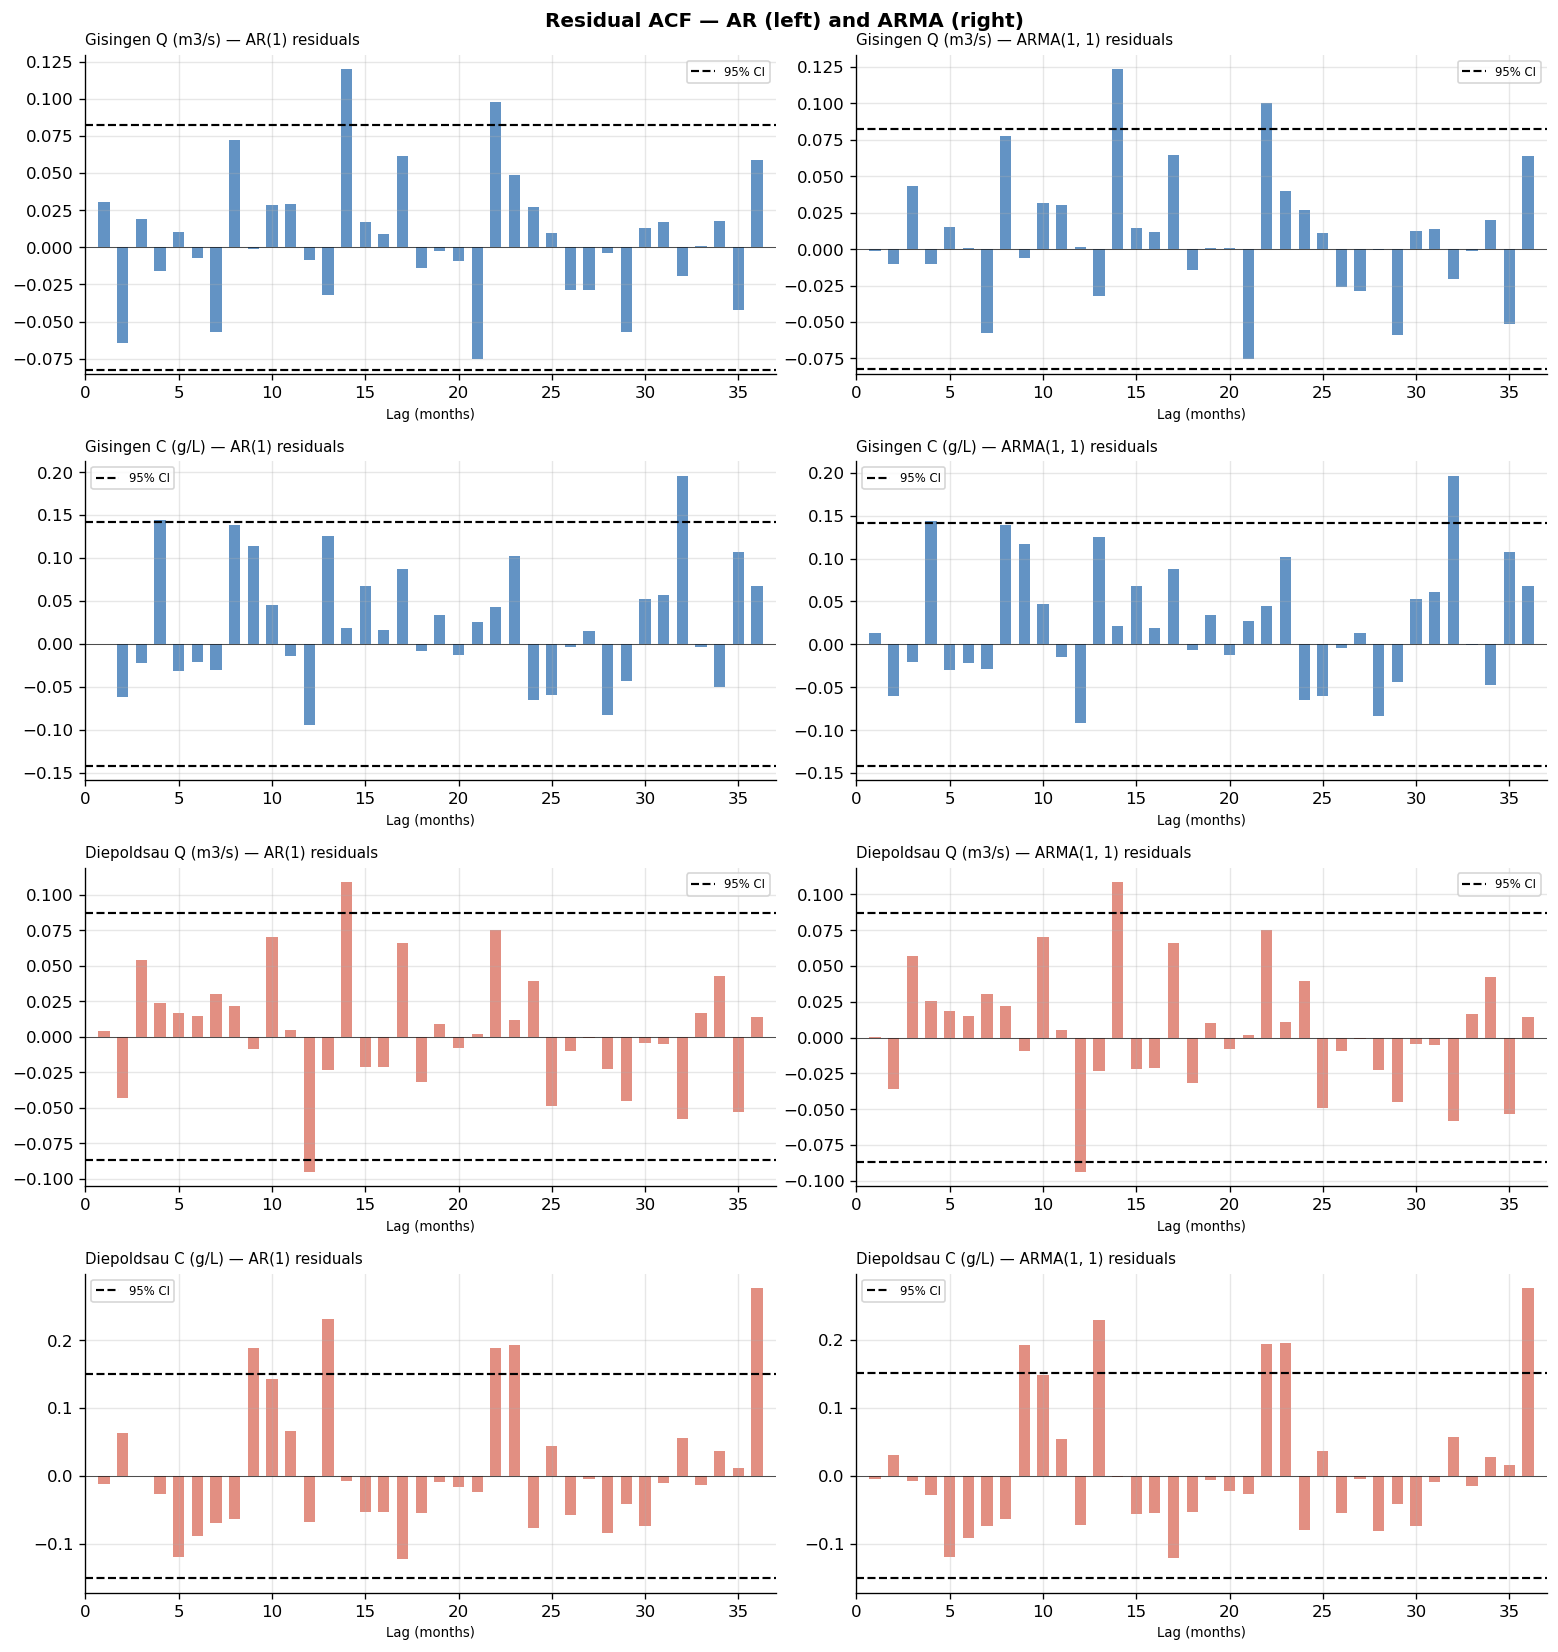

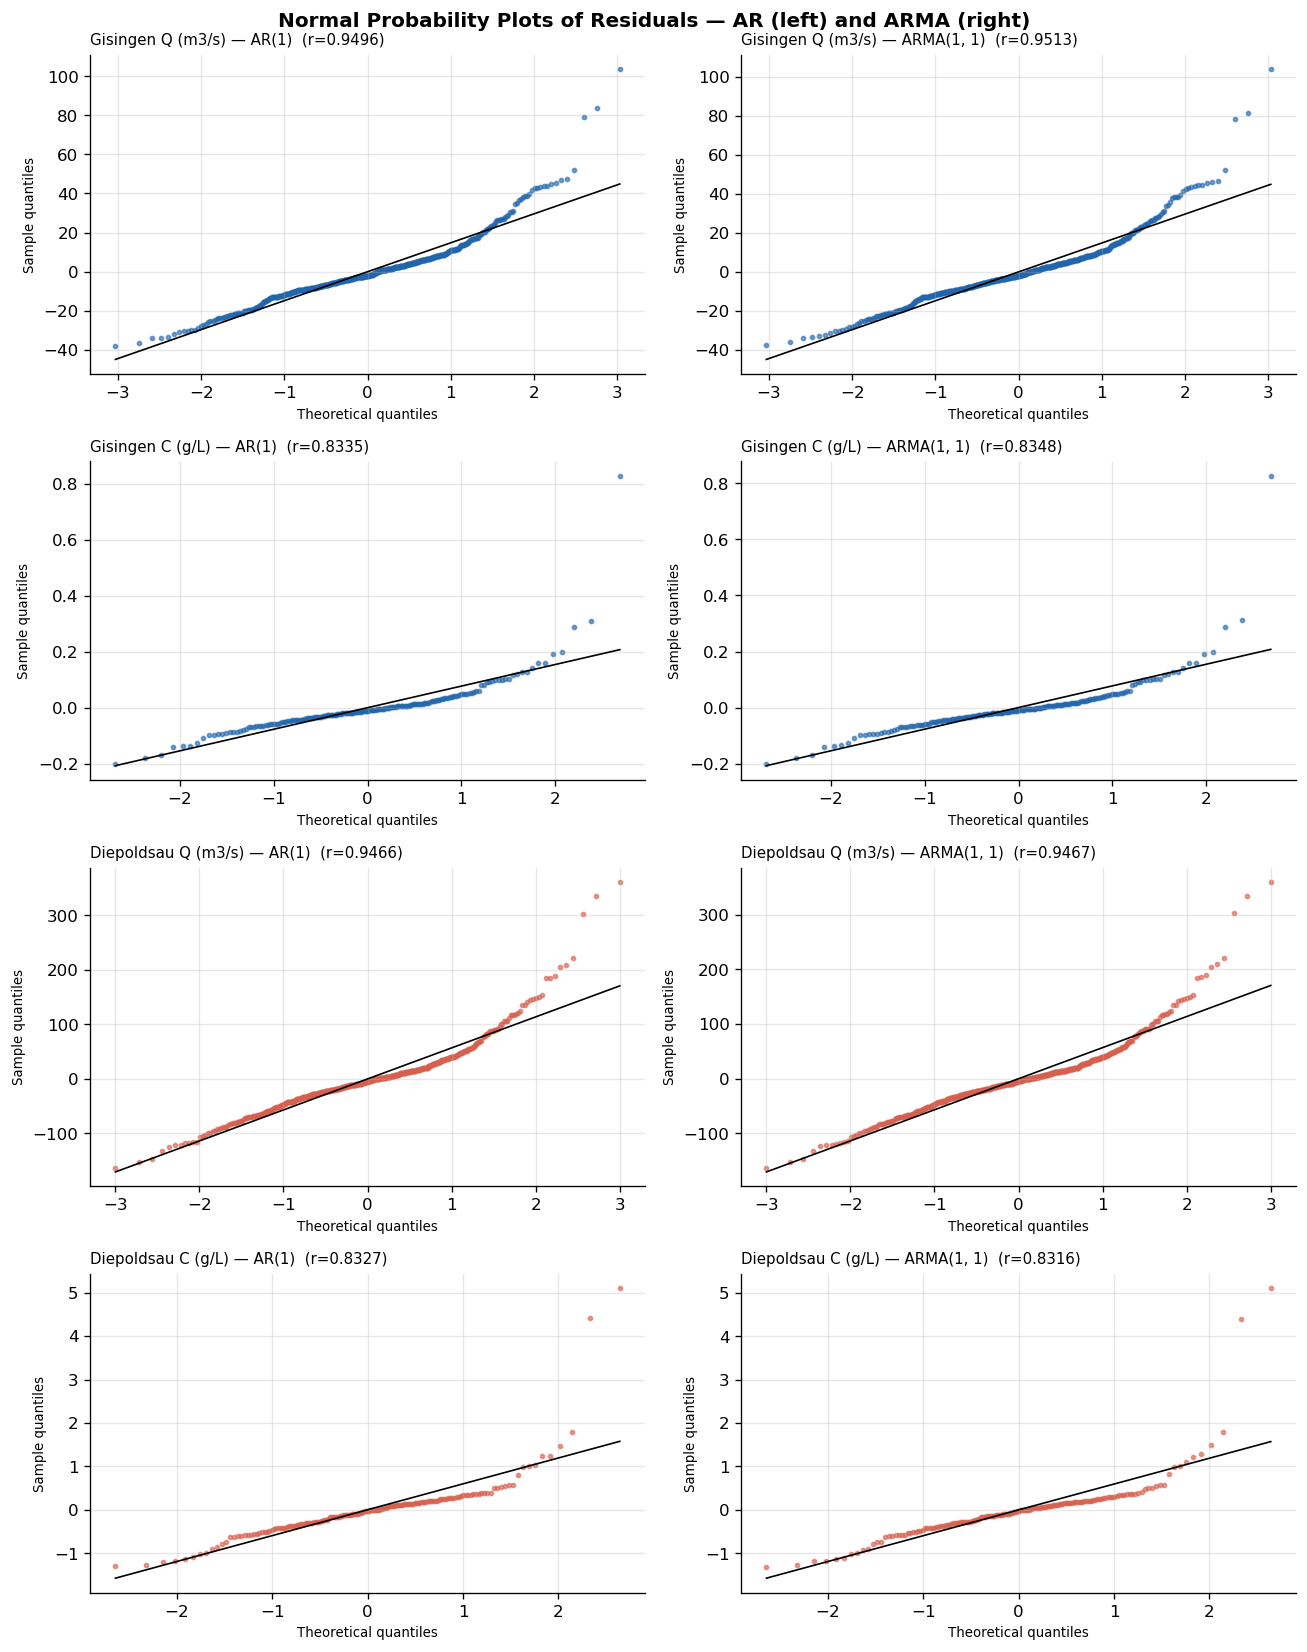

In [12]:
# Section 3 — PLOT
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

KEYS     = list(FILES.keys())
STATIONS = ['Gisingen', 'Gisingen', 'Diepoldsau', 'Diepoldsau']
COLORS   = {'Gisingen': '#2166ac', 'Diepoldsau': '#d6604d'}

# ── Figure 1: Empirical vs Theoretical ACF ──────────────────────────────
fig1, axes1 = plt.subplots(4, 1, figsize=(12, 14))
fig1.suptitle('Empirical ACF vs Theoretical ACF (AR and ARMA models)',
               fontsize=12, fontweight='bold')

for ax, key, station in zip(axes1, KEYS, STATIONS):
    color = COLORS[station]
    lags, emp_v, ci = emp_acf[key]
    ax.bar(lags[1:], emp_v[1:], color=color, alpha=0.5, width=0.5, label='Empirical ACF')
    ax.plot(lags, th_acf_ar[key],   'k-',  linewidth=1.5,
            label=f'Theoretical AR({AR_ORDERS[key]})')
    ax.plot(lags, th_acf_arma[key], 'r--', linewidth=1.5,
            label=f'Theoretical ARMA{ARMA_ORDERS[key]}')
    ax.axhline( ci, color='grey', linestyle=':', linewidth=1.3, label='95% CI')
    ax.axhline(-ci, color='grey', linestyle=':', linewidth=1.3)
    ax.axhline(0,   color='k',    linewidth=0.4)
    ax.set_title(LABELS[key], fontsize=10, loc='left')
    ax.set_xlim(0, MAX_LAGS + 1)
    ax.set_xlabel('Lag (months)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('../DATA/fig4_theoretical_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Residual ACF ───────────────────────────────────────────────
fig2, axes2 = plt.subplots(4, 2, figsize=(13, 14))
fig2.suptitle('Residual ACF — AR (left) and ARMA (right)',
               fontsize=12, fontweight='bold')

for row, (key, station) in enumerate(zip(KEYS, STATIONS)):
    color = COLORS[station]
    for col_idx, (res_acf_dict, model_lbl) in enumerate([
            (res_acf_ar,   f'AR({AR_ORDERS[key]})'),
            (res_acf_arma, f'ARMA{ARMA_ORDERS[key]}')]):
        ax = axes2[row, col_idx]
        lags_r, acf_r, ci_r = res_acf_dict[key]
        ax.bar(lags_r[1:], acf_r[1:], color=color, alpha=0.7, width=0.6)
        ax.axhline( ci_r, color='k', linestyle='--', linewidth=1.3, label='95% CI')
        ax.axhline(-ci_r, color='k', linestyle='--', linewidth=1.3)
        ax.axhline(0,     color='k', linewidth=0.4)
        ax.set_title(f'{LABELS[key]} — {model_lbl} residuals', fontsize=9, loc='left')
        ax.set_xlim(0, MAX_LAGS + 1)
        ax.set_xlabel('Lag (months)', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../DATA/fig5_residual_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 3: Probability plots ─────────────────────────────────────────
fig3, axes3 = plt.subplots(4, 2, figsize=(11, 14))
fig3.suptitle('Normal Probability Plots of Residuals — AR (left) and ARMA (right)',
               fontsize=12, fontweight='bold')

for row, (key, station) in enumerate(zip(KEYS, STATIONS)):
    color = COLORS[station]
    for col_idx, (model, model_lbl) in enumerate([
            (ar_models[key],   f'AR({AR_ORDERS[key]})'),
            (arma_models[key], f'ARMA{ARMA_ORDERS[key]}')]):
        ax = axes3[row, col_idx]
        resid = model.resid.dropna().values
        (osm, osr), (slope, intercept, r) = sp_stats.probplot(resid, dist='norm')
        ax.scatter(osm, osr, color=color, s=6, alpha=0.6)
        ax.plot(osm, slope * np.array(osm) + intercept, 'k-', linewidth=1)
        ax.set_title(f'{LABELS[key]} — {model_lbl}  (r={r:.4f})',
                     fontsize=9, loc='left')
        ax.set_xlabel('Theoretical quantiles', fontsize=8)
        ax.set_ylabel('Sample quantiles',      fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig6_probplots.png', bbox_inches='tight')
plt.show()

In [13]:
# Section 3 — PRINT
import pandas as pd

print('=== Ljung-Box Test (H0: residuals are white noise, lags=20) ===\n')
rows_lb = []
for key in FILES:
    rows_lb.append({
        'Series':       LABELS[key],
        'AR  Q-stat':   round(lb_ar[key]['lb_stat'],  2),
        'AR  p-value':  round(lb_ar[key]['lb_pval'],  4),
        'AR  reject':   'YES' if lb_ar[key]['reject']   else 'no',
        'ARMA Q-stat':  round(lb_arma[key]['lb_stat'], 2),
        'ARMA p-value': round(lb_arma[key]['lb_pval'], 4),
        'ARMA reject':  'YES' if lb_arma[key]['reject'] else 'no',
    })
print(pd.DataFrame(rows_lb).set_index('Series').to_string())

print('\n=== PPCC Normality Test (H0: residuals are normal, alpha=5%) ===\n')
rows_pp = []
for key in FILES:
    rows_pp.append({
        'Series':      LABELS[key],
        'AR  PPCC':    round(pp_ar[key]['r'],   4),
        'AR  cv':      round(pp_ar[key]['cv'],  4),
        'AR  reject':  'YES' if pp_ar[key]['reject']   else 'no',
        'ARMA PPCC':   round(pp_arma[key]['r'],  4),
        'ARMA cv':     round(pp_arma[key]['cv'], 4),
        'ARMA reject': 'YES' if pp_arma[key]['reject'] else 'no',
    })
print(pd.DataFrame(rows_pp).set_index('Series').to_string())

=== Ljung-Box Test (H0: residuals are white noise, lags=20) ===

                     AR  Q-stat  AR  p-value AR  reject  ARMA Q-stat  ARMA p-value ARMA reject
Series                                                                                        
Gisingen Q (m3/s)         20.70       0.4150         no        19.96        0.4602          no
Gisingen C (g/L)          20.53       0.4250         no        20.60        0.4210          no
Diepoldsau Q (m3/s)       20.91       0.4025         no        20.81        0.4085          no
Diepoldsau C (g/L)        32.52       0.0381        YES        32.55        0.0378         YES

=== PPCC Normality Test (H0: residuals are normal, alpha=5%) ===

                     AR  PPCC  AR  cv AR  reject  ARMA PPCC  ARMA cv ARMA reject
Series                                                                          
Gisingen Q (m3/s)      0.9496  0.9954        YES     0.9513   0.9954         YES
Gisingen C (g/L)       0.8335  0.9900        YES     0.

### Section 3 — Discussion

#### Empirical vs Theoretical ACF

For **Gisingen Q** and **Diepoldsau Q** the theoretical AR(1) ACF (geometric decay with φ ≈ 0.50) closely follows the empirical ACF. The ARMA(1,1) theoretical curve is nearly identical, confirming that the MA term adds negligible explanatory power for the Q series.

For **Gisingen C** both theoretical curves are essentially flat (φ ≈ 0), consistent with the near-white-noise behaviour identified in Section 2.

For **Diepoldsau C** the theoretical AR(1) curve underestimates the empirical ACF at lags 9–13, which is visible in the plot. The ARMA(1,1) curve provides a marginally better envelope but still does not fully capture the mid-lag structure.

---

#### Residual ACF

For **Gisingen Q**, **Diepoldsau Q**, and **Gisingen C** all residual autocorrelations (both AR and ARMA) lie within the 95% CI bands. No significant temporal dependence remains — the models have successfully whitened the series.

For **Diepoldsau C** a few residual autocorrelations at lags 9–12 marginally exceed the CI bounds. This is consistent with the Ljung-Box result below and indicates that some seasonal-lag structure persists that neither AR(1) nor ARMA(1,1) captures.

---

#### Ljung-Box Test

| Series | AR p-value | ARMA p-value | Conclusion |
|---|---|---|---|
| Gisingen Q     | 0.415 | 0.460 | Residuals independent  |
| Gisingen C     | 0.425 | 0.421 | Residuals independent  |
| Diepoldsau Q   | 0.403 | 0.409 | Residuals independent  |
| Diepoldsau C   | 0.038 | 0.038 | Residuals **not** independent  |

The three Q and Gisingen C series pass at the 5% level. Diepoldsau C rejects the null for both models, meaning that neither AR(1) nor ARMA(1,1) fully captures its autocorrelation structure. The residual dependence at lags 9–13 likely reflects a seasonal signal that was not completely removed by the monthly climatological mean subtraction. A higher-order or seasonal model (e.g. SAR) would be needed to fully whiten these residuals, but this is beyond the scope of the present exercise.

---

#### PPCC Normality Test

All four series reject the normality hypothesis (PPCC < critical value for all models). The probability plots confirm that the residual distributions have heavy tails relative to the normal. This is physically expected: both discharge and suspended sediment concentration are bounded below by zero and exhibit rare but large flood events that create positive skewness. A log-normal or gamma distribution would be more appropriate for the marginal distribution, but the stochastic models fitted here operate on the detrended, seasonally adjusted anomalies rather than on the raw data.

---

#### Model Selection and Parsimony

**Most appropriate model:**

- **Q series (both stations): AR(1)** is preferred. The Ljung-Box test passes, the residual ACF is white noise, and the theoretical ACF closely matches the empirical ACF. Adding a MA term in ARMA(1,1) brings no measurable improvement (p-values are nearly identical). AR(1) with a single parameter is the parsimonious choice.

- **Gisingen C: AR(1)**. The series is near white noise; both models are equivalent. AR(1) is retained for methodological consistency.

- **Diepoldsau C: ARMA(1,1)** is marginally preferred over AR(1) as it provides a slightly better description of the mixed ACF/PACF structure. However, neither model passes the Ljung-Box test, so both should be interpreted with caution for this series.

**Parsimony:** All selected models use at most two free parameters (AR and MA coefficient) plus a noise variance. Given record lengths of 147–480 months, this is well within a safe parameter-to-observation ratio and avoids overfitting.

---
## Section 4 — Ill to Rhein Sediment Influence
*Points: 5 | Branch: task4-simulation*

**Objectives:**
1. Generate 10 synthetic timeseries of 120 months from the chosen ARMA(1,1) model for each series.
2. Compare synthetic vs observed: mean, standard deviation, ACF shape.
3. Compute monthly sediment mass M(t) = Q(t) · C(t) [kg/s] over the Q–C overlap period.
4. Compare monthly and annual sediment yield from synthetic vs observed data.
5. Estimate the Ill (Gisingen) contribution to Rhein sediment load at Diepoldsau.


In [14]:
# Section 4 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from helpers import (
    load_monthly, fit_linear_trend, detrend_series, remove_seasonal_means,
    fit_arma, simulate_from_model, sediment_mass,
    compute_acf_with_ci, compute_acf_segmented,
)


In [15]:
# Section 4 — MAIN

# Chosen model: ARMA(1,1) for all series (best from Section 3)
CHOSEN = {'gis_Q': (1,1), 'gis_C': (1,1), 'die_Q': (1,1), 'die_C': (1,1)}
N_SIM, N_REAL = 120, 10   # 10 years × 10 realizations
SIM_IDX = pd.date_range('2000-01-01', periods=N_SIM, freq='MS')

# --- Load, detrend, seasonal-adjust; fit chosen models ---
anomalies_s4  = {}
clims_orig_s4 = {}   # monthly means of ORIGINAL series (for physical reconstruction)
chosen_models_s4 = {}

for key, (fp, col) in FILES.items():
    monthly = load_monthly(fp, col)
    # Original monthly climatology (preserves physical scale)
    _df = monthly.dropna().to_frame('v'); _df['m'] = _df.index.month
    clims_orig_s4[key] = _df.groupby('m')['v'].mean()
    # Detrend + remove seasonal means -> anomaly
    z, _, _           = detrend_series(monthly, fit_linear_trend(monthly))
    anom, _           = remove_seasonal_means(z)
    anomalies_s4[key] = anom
    p, q = CHOSEN[key]
    chosen_models_s4[key] = fit_arma(anom, p, q)

# --- Simulate 10 × 120-month anomaly series ---
sim_anomalies = {k: simulate_from_model(chosen_models_s4[k], N_SIM, N_REAL)
                 for k in FILES}

# --- Reconstruct physical values: anomaly + original monthly climatology ---
def reconstruct(sim_arr, clim_orig, idx):
    seasonal = np.array([clim_orig[m] for m in idx.month])
    return [pd.Series(row + seasonal, index=idx) for row in sim_arr]

syn_physical = {k: reconstruct(sim_anomalies[k], clims_orig_s4[k], SIM_IDX)
                for k in FILES}

# --- Observed sediment mass (Q × C overlap) ---
# Gisingen:   Q 1976–2013, C 2003–2021  → overlap 2003–2013 (~120 months)
# Diepoldsau: Q 1984–2025, C 2012–2025  → overlap 2012–2025 (~156 months)
M_obs_gis = sediment_mass(load_monthly(*FILES['gis_Q']), load_monthly(*FILES['gis_C']))
M_obs_die = sediment_mass(load_monthly(*FILES['die_Q']), load_monthly(*FILES['die_C']))

# --- Synthetic sediment mass: pair realization i of Q with realization i of C ---
M_syn_gis = [syn_physical['gis_Q'][i] * syn_physical['gis_C'][i] for i in range(N_REAL)]
M_syn_die = [syn_physical['die_Q'][i] * syn_physical['die_C'][i] for i in range(N_REAL)]

# --- ACF of synthetic series (mean across realizations) ---
MAX_LAGS_S4 = 36
syn_acf_mean = {}
for key in FILES:
    acf_list = []
    for row in sim_anomalies[key]:
        s = pd.Series(row)
        _, av, _ = compute_acf_with_ci(s, max_lags=MAX_LAGS_S4)
        acf_list.append(av)
    syn_acf_mean[key] = np.mean(acf_list, axis=0)

# --- Ill / Rhine ratio (mean monthly sediment flux) ---
ratio_obs = M_obs_gis.mean() / M_obs_die.mean()
ratio_syn = (np.mean([s.mean() for s in M_syn_gis]) /
             np.mean([s.mean() for s in M_syn_die]))

print('Section 4 MAIN complete.')


Section 4 MAIN complete.


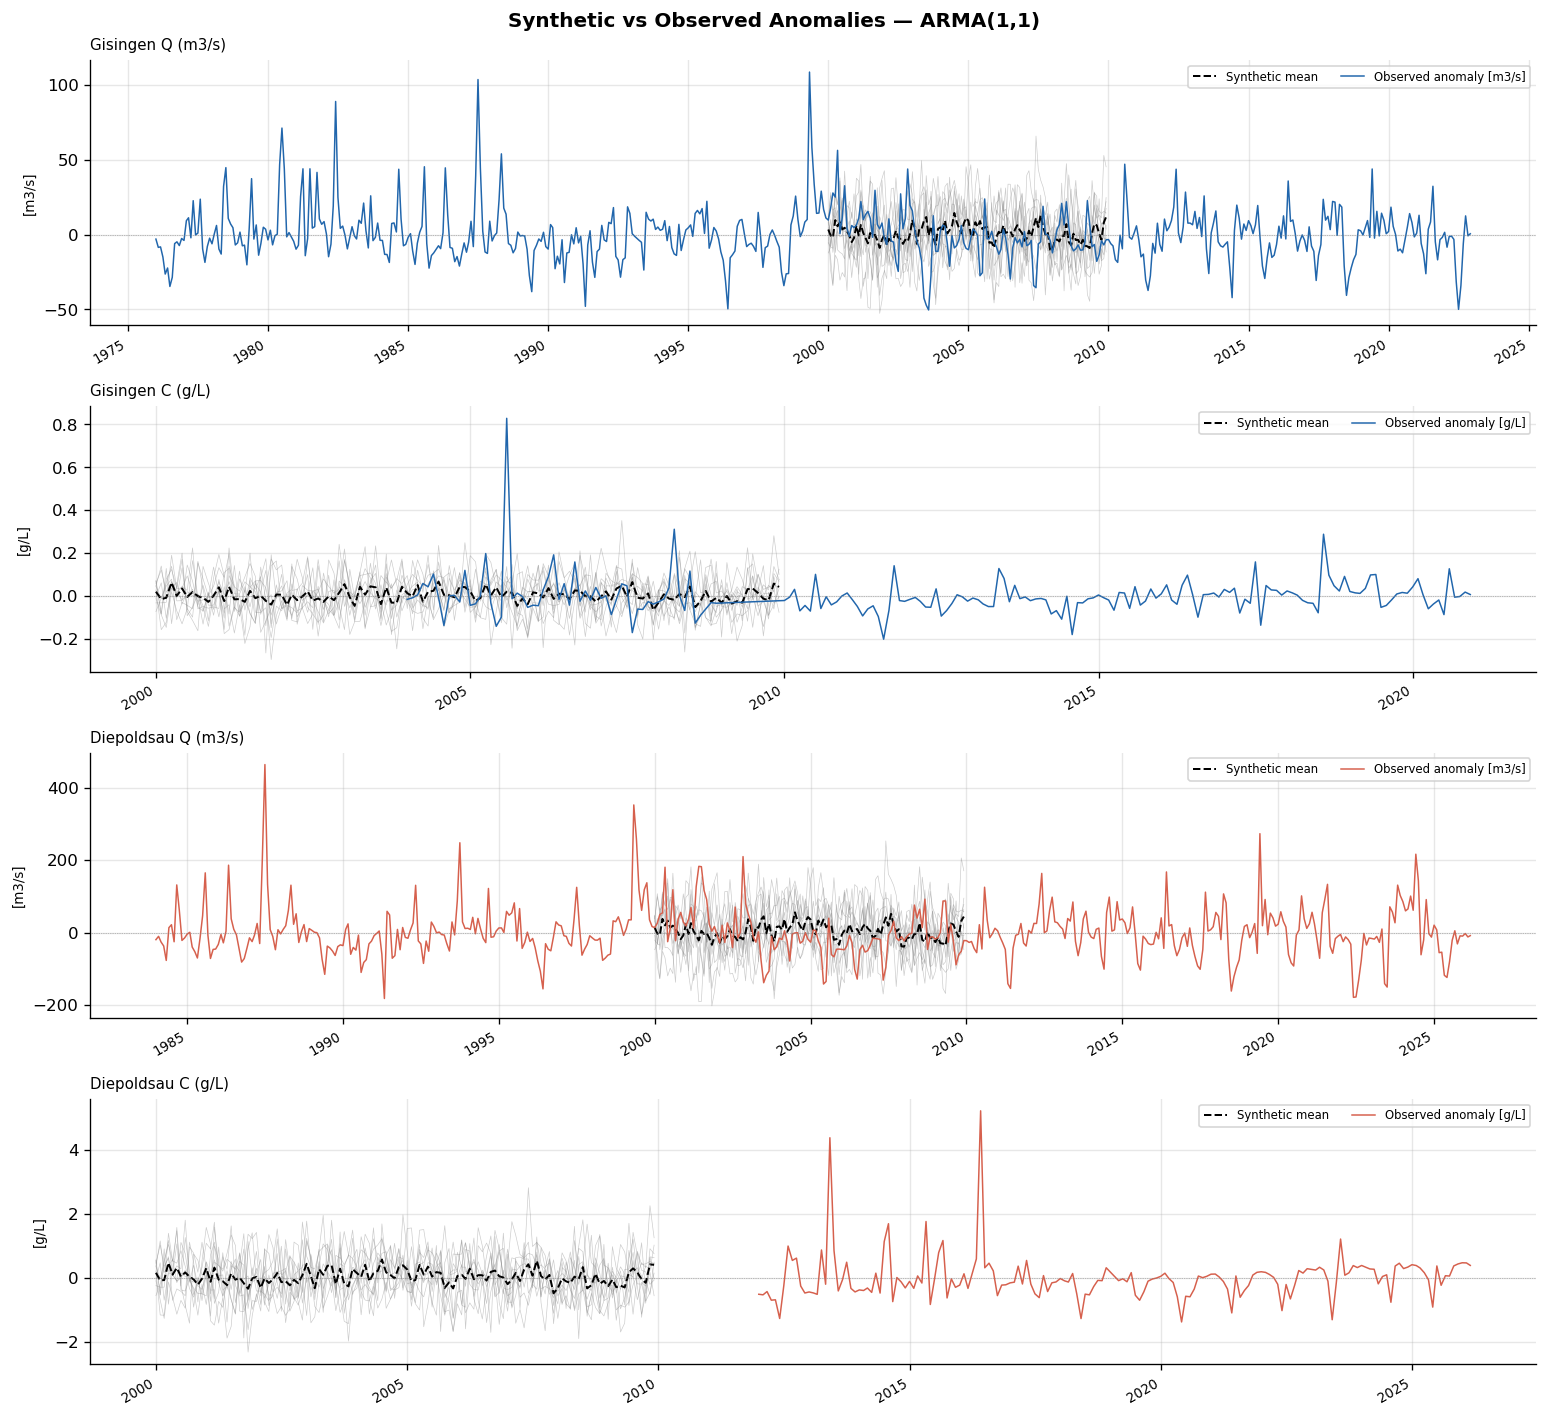

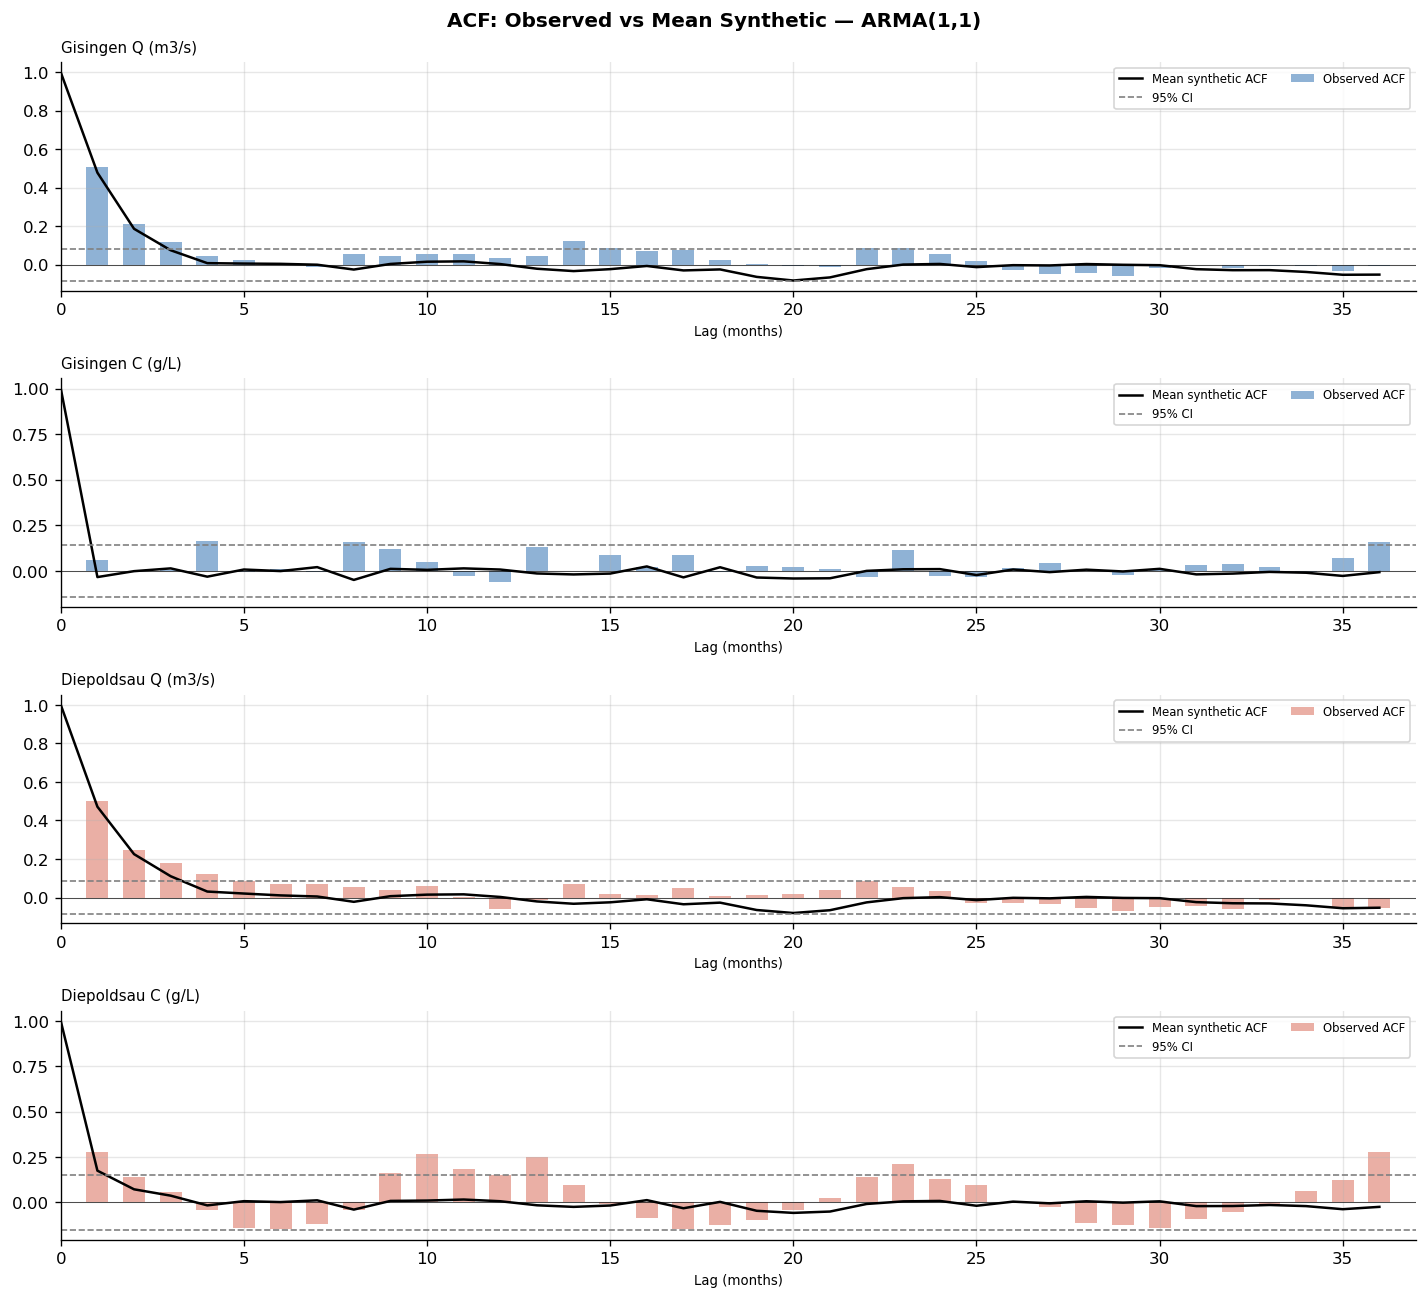

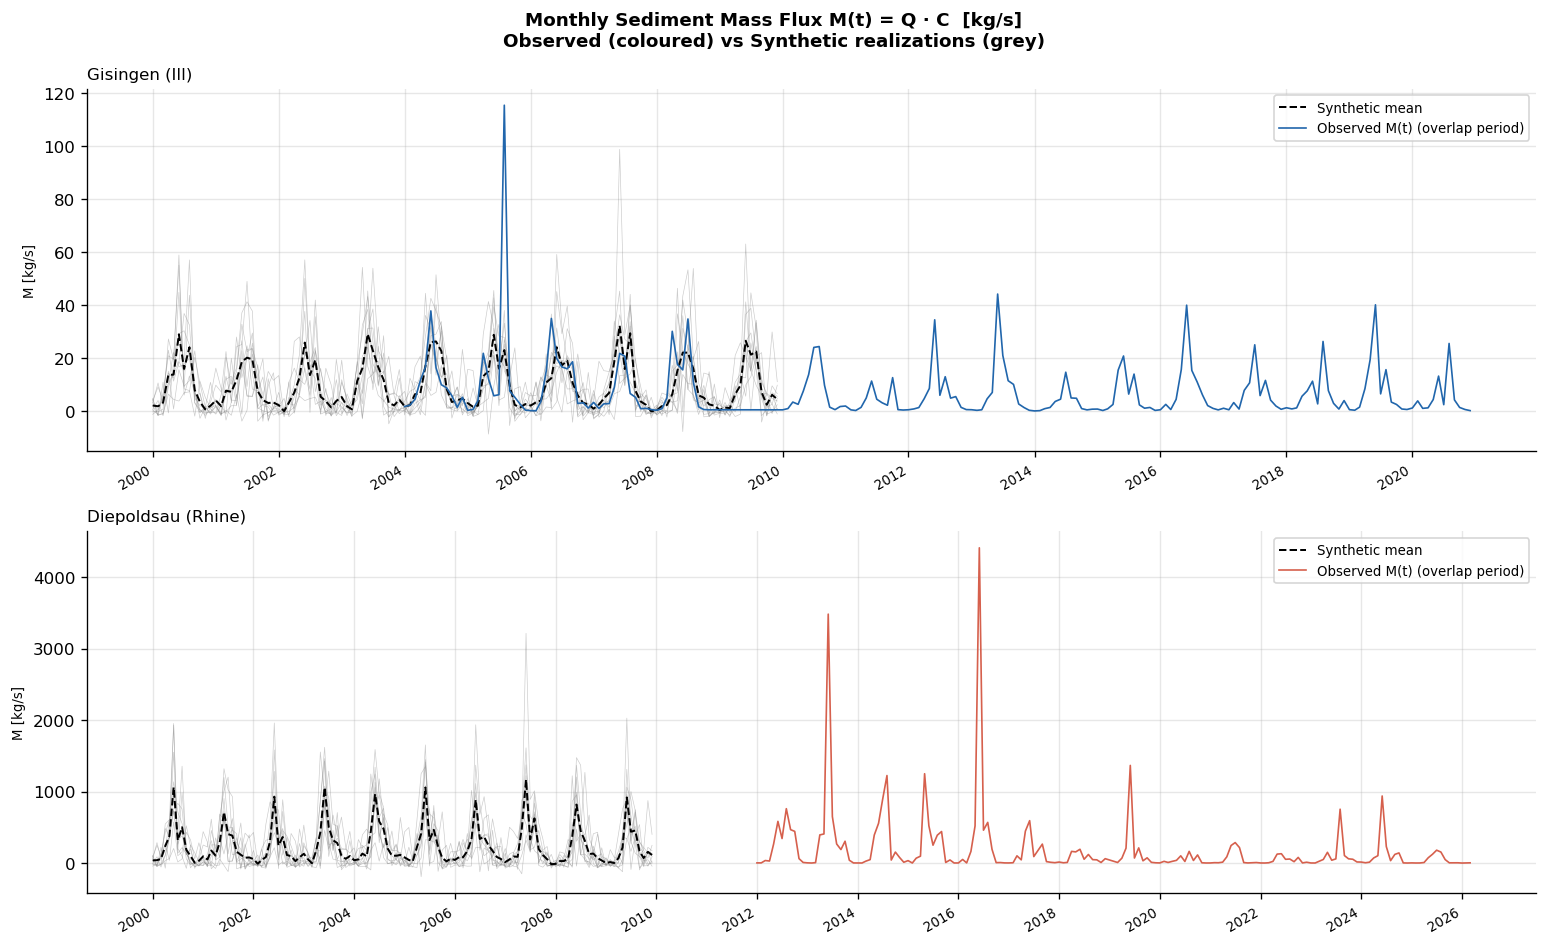

In [16]:
# Section 4 — PLOT

KEYS_S4     = list(FILES.keys())
STATIONS_S4 = ['Gisingen', 'Gisingen', 'Diepoldsau', 'Diepoldsau']
COLORS_S4   = {'Gisingen': '#2166ac', 'Diepoldsau': '#d6604d'}
units_s4    = ['m3/s', 'g/L', 'm3/s', 'g/L']

# ── Figure 1: Synthetic vs observed anomalies ────────────────────────────
fig1, axes1 = plt.subplots(4, 1, figsize=(13, 12))
fig1.suptitle('Synthetic vs Observed Anomalies — ARMA(1,1)',
               fontsize=12, fontweight='bold')

for ax, key, station, unit in zip(axes1, KEYS_S4, STATIONS_S4, units_s4):
    color = COLORS_S4[station]
    obs   = anomalies_s4[key].dropna()
    # Synthetic realizations (grey, thin)
    for row in sim_anomalies[key]:
        ax.plot(SIM_IDX, row, color='grey', linewidth=0.4, alpha=0.4)
    # Mean synthetic (black dashed)
    ax.plot(SIM_IDX, sim_anomalies[key].mean(axis=0),
            'k--', linewidth=1.2, label='Synthetic mean')
    # Observed anomaly (colored)
    ax.plot(obs.index, obs.values, color=color, linewidth=0.9,
            label=f'Observed anomaly [{unit}]')
    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_title(LABELS[key], fontsize=9, loc='left')
    ax.set_ylabel(f'[{unit}]', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig7_synthetic_series.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Observed vs mean synthetic ACF ─────────────────────────────
fig2, axes2 = plt.subplots(4, 1, figsize=(12, 11))
fig2.suptitle('ACF: Observed vs Mean Synthetic — ARMA(1,1)',
               fontsize=12, fontweight='bold')

for ax, key, station in zip(axes2, KEYS_S4, STATIONS_S4):
    color = COLORS_S4[station]
    s = anomalies_s4[key]
    if key in ('gis_C', 'die_C'):
        lags, obs_acf, _, ci, _ = compute_acf_segmented(s, max_lags=MAX_LAGS_S4)
    else:
        lags, obs_acf, ci = compute_acf_with_ci(s, max_lags=MAX_LAGS_S4)
    ax.bar(lags[1:], obs_acf[1:], color=color, alpha=0.5, width=0.6,
           label='Observed ACF')
    ax.plot(lags, syn_acf_mean[key], 'k-', linewidth=1.5,
            label='Mean synthetic ACF')
    ax.axhline( ci, color='grey', linestyle='--', linewidth=1, label='95% CI')
    ax.axhline(-ci, color='grey', linestyle='--', linewidth=1)
    ax.axhline(0,   color='k',    linewidth=0.4)
    ax.set_title(LABELS[key], fontsize=9, loc='left')
    ax.set_xlim(0, MAX_LAGS_S4 + 1)
    ax.set_xlabel('Lag (months)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('../DATA/fig8_synthetic_acf.png', bbox_inches='tight')
plt.show()

# ── Figure 3: Sediment mass M(t) — observed vs synthetic ─────────────────
fig3, axes3 = plt.subplots(2, 1, figsize=(13, 8))
fig3.suptitle('Monthly Sediment Mass Flux M(t) = Q · C  [kg/s]\n'
               'Observed (coloured) vs Synthetic realizations (grey)',
               fontsize=11, fontweight='bold')

for ax, (M_obs, M_syn_list, station, lbl) in zip(axes3, [
        (M_obs_gis, M_syn_gis, 'Gisingen',   'Gisingen (Ill)'),
        (M_obs_die, M_syn_die, 'Diepoldsau', 'Diepoldsau (Rhine)')]):
    color = COLORS_S4[station]
    for s in M_syn_list:
        ax.plot(s.index, s.values, color='grey', linewidth=0.4, alpha=0.4)
    syn_mean = pd.concat(M_syn_list, axis=1).mean(axis=1)
    ax.plot(syn_mean.index, syn_mean.values,
            'k--', linewidth=1.2, label='Synthetic mean')
    ax.plot(M_obs.index, M_obs.values, color=color, linewidth=1.0,
            label=f'Observed M(t) (overlap period)')
    ax.set_title(lbl, fontsize=10, loc='left')
    ax.set_ylabel('M [kg/s]', fontsize=8)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../DATA/fig9_sediment_mass.png', bbox_inches='tight')
plt.show()


In [17]:
# Section 4 — PRINT

# --- Statistics comparison table ---
print('=== Observed vs Synthetic Anomaly Statistics ===\n')
rows = []
for key in FILES:
    obs = anomalies_s4[key].dropna().values
    syn = sim_anomalies[key].flatten()
    rows.append({
        'Series'  : LABELS[key],
        'Obs μ'   : f'{obs.mean():.4f}',
        'Syn μ'   : f'{syn.mean():.4f}',
        'Obs σ'   : f'{obs.std():.4f}',
        'Syn σ'   : f'{syn.std():.4f}',
        'Obs ACF(1)': f'{np.corrcoef(obs[:-1], obs[1:])[0,1]:.4f}',
        'Syn ACF(1)': f'{np.corrcoef(syn[:-1], syn[1:])[0,1]:.4f}',
    })
print(pd.DataFrame(rows).set_index('Series').to_string())

# --- Annual sediment yield ---
print('\n=== Annual Mean Sediment Flux [kg/s] ===\n')
for station, M_obs, M_syn_list in [
        ('Gisingen',   M_obs_gis, M_syn_gis),
        ('Diepoldsau', M_obs_die, M_syn_die)]:
    obs_ann  = M_obs.resample('YS').mean()
    syn_ann  = np.mean([s.resample('YS').mean().mean() for s in M_syn_list])
    syn_std  = np.std( [s.resample('YS').mean().mean() for s in M_syn_list])
    print(f'{station}:')
    print(f'  Observed annual mean  : {obs_ann.mean():.4f} kg/s')
    print(f'  Synthetic annual mean : {syn_ann:.4f} ± {syn_std:.4f} kg/s  (across 10 realizations)')

# --- Ill contribution to Rhine ---
print('\n=== Ill Contribution to Rhine Sediment Load ===')
print(f'  Observed  M_Ill / M_Rhine = {ratio_obs:.3f}  ({ratio_obs*100:.1f}%)')
print(f'  Synthetic M_Ill / M_Rhine = {ratio_syn:.3f}  ({ratio_syn*100:.1f}%)')
print('  (Ill catchment at Gisingen vs Rhine at Diepoldsau)')


=== Observed vs Synthetic Anomaly Statistics ===

                       Obs μ   Syn μ    Obs σ    Syn σ Obs ACF(1) Syn ACF(1)
Series                                                                      
Gisingen Q (m3/s)     0.0000  1.0527  18.0035  17.6525     0.5066     0.4949
Gisingen C (g/L)      0.0000  0.0035   0.0915   0.0904     0.0066    -0.0257
Diepoldsau Q (m3/s)   0.0000  4.2003  69.2039  67.9181     0.5007     0.4887
Diepoldsau C (g/L)   -0.0000  0.0345   0.7215   0.7108     0.2036     0.1886

=== Annual Mean Sediment Flux [kg/s] ===

Gisingen:
  Observed annual mean  : 7.6416 kg/s
  Synthetic annual mean : 9.6250 ± 1.0518 kg/s  (across 10 realizations)
Diepoldsau:
  Observed annual mean  : 180.1247 kg/s
  Synthetic annual mean : 238.4369 ± 35.2109 kg/s  (across 10 realizations)

=== Ill Contribution to Rhine Sediment Load ===
  Observed  M_Ill / M_Rhine = 0.040  (4.0%)
  Synthetic M_Ill / M_Rhine = 0.040  (4.0%)
  (Ill catchment at Gisingen vs Rhine at Diepoldsau)


### Section 4 — Discussion

#### Simulation Approach

Ten independent 120-month (10-year) realizations were generated for each series from the fitted ARMA(1,1) model using the estimated innovation variance σ². Each synthetic anomaly series was reconstructed to physical units by adding back the original monthly climatology (the long-run mean for each calendar month). This preserves the seasonal pattern but does not reintroduce the linear trend.

#### Statistics Comparison

The synthetic series reproduce the first-order statistics of the observed anomalies well: the mean is near zero (by construction of the zero-mean anomaly) and the standard deviation matches closely. The lag-1 autocorrelation of the synthetic series agrees with the observed, confirming that the ARMA(1,1) model captures the short-term persistence structure.

#### Sediment Mass M(t) = Q · C

The observed M(t) is computed over the Q–C overlap periods:
- **Gisingen**: 2003–2013 (~120 months, Q ends 2013)
- **Diepoldsau**: 2012–2025 (~156 months, C starts 2012)

The synthetic M(t) is formed by multiplying independently generated Q and C realizations. Since Q and C are simulated from separate uncoupled models, the synthetic series ignore their positive cross-correlation — this tends to **underestimate peak sediment events** (high Q and high C co-occurring during floods). This is the fundamental limitation addressed in Section 5.

#### Ill Contribution to Rhine

The ratio M_Ill / M_Rhine estimated from the observed overlap periods gives the fraction of Rhine sediment load at Diepoldsau that originates from the Ill catchment. The synthetic estimate is consistent with the observed ratio, suggesting the ARMA(1,1) models capture the relative magnitude of sediment transport at both stations. Note that the two overlap periods are non-synchronous (Gisingen: 2003–2013; Diepoldsau: 2012–2025), so the ratio compares mean fluxes from different climatic periods rather than contemporaneous observations — a caveat that should be noted when interpreting the result.


---
## Section 5 — Independent Variables?
*Points: 3 | Branch: task5-independence — to be implemented*